# harmful text detection

multi-label classification of harmful content in freelancer platform text.

dataset: jigsaw toxic comment classification + civil comments (huggingface, real data, no synthetic)
models: bert, roberta, distilbert
labels: toxicity, obscene, threat, insult, identity_hate

## 0. install dependencies

In [1]:
!pip install -q transformers torch scikit-learn pandas numpy joblib tqdm datasets
!pip install -q --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121

## 1. imports

In [2]:
import os, random
import pandas as pd
import numpy as np
import torch
import re
import json as json_lib
import joblib
import shutil
import zipfile
import datetime
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss, accuracy_score,
    precision_score, recall_score, f1_score, fbeta_score, jaccard_score,
    matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, confusion_matrix,
)
import time

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

LABEL_SCHEMA = {
    "toxicity": 0,
    "obscene": 1,
    "threat": 2,
    "insult": 3,
    "identity_hate": 4,
}
REVERSE_LABEL_SCHEMA = {v: k for k, v in LABEL_SCHEMA.items()}
LABEL_NAMES = list(LABEL_SCHEMA.keys())
NUM_LABELS = len(LABEL_SCHEMA)

print('imports successful')
print(f'pytorch: {torch.__version__}')
print(f'device: {"cuda" if torch.cuda.is_available() else "cpu"}')
if torch.cuda.is_available():
    print(f'cuda: {torch.version.cuda}')
    print(f'gpu: {torch.cuda.get_device_name(0)}')
    try:
        x = torch.randn(10, 10).cuda()
        y = x @ x
        print('gpu computation: ok')
    except Exception as e:
        print(f'gpu computation failed: {e}')

imports successful
pytorch: 2.10.0+cu128
device: cuda
cuda: 12.8
gpu: Tesla T4
gpu computation: ok


## 2. build dataset (jigsaw + civil comments)

In [3]:
RARE_LABELS = ['identity_hate', 'threat']
SCORE_THR   = 0.5

# target sizes, roughly 50/50 toxic/clean split
N_RARE  = 11000
N_OTHER = 7000
N_CLEAN = 15000

print(f'labels: {LABEL_NAMES}')
print(f'target: {N_RARE+N_OTHER} toxic + {N_CLEAN} clean = {N_RARE+N_OTHER+N_CLEAN:,} rows')

labels: ['toxicity', 'obscene', 'threat', 'insult', 'identity_hate']
target: 18000 toxic + 15000 clean = 33,000 rows


In [4]:
print('loading jigsaw...')
jigsaw_raw = load_dataset('thesofakillers/jigsaw-toxic-comment-classification-challenge', split='train')
jigsaw_src_df = jigsaw_raw.to_pandas()
jigsaw_src_df = jigsaw_src_df.rename(columns={'comment_text': 'text', 'toxic': 'toxicity', 'severe_toxic': 'severe_toxicity'})

# merge severe_toxicity into toxicity
jigsaw_src_df['toxicity'] = ((jigsaw_src_df['toxicity'] == 1) | (jigsaw_src_df.get('severe_toxicity', 0) == 1)).astype(int)

for lbl in LABEL_NAMES:
    jigsaw_src_df[lbl] = jigsaw_src_df[lbl].fillna(0).astype(int) if lbl in jigsaw_src_df.columns else 0

jigsaw_src_df = jigsaw_src_df[['text'] + LABEL_NAMES].dropna(subset=['text'])
jigsaw_src_df['text']   = jigsaw_src_df['text'].astype(str).str.strip()
jigsaw_src_df           = jigsaw_src_df[jigsaw_src_df['text'].str.len() > 10].reset_index(drop=True)
jigsaw_src_df['source'] = 'jigsaw'

any_toxic = jigsaw_src_df[LABEL_NAMES].sum(axis=1) > 0
print(f'rows: {len(jigsaw_src_df):,}  toxic: {any_toxic.sum():,} ({any_toxic.mean()*100:.1f}%)')
for lbl in LABEL_NAMES:
    n = jigsaw_src_df[lbl].sum()
    print(f'  {lbl:20s}: {n:6,} ({n/len(jigsaw_src_df)*100:.2f}%)')

loading jigsaw...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

rows: 159,566  toxic: 16,223 (10.2%)
  toxicity            : 15,292 (9.58%)
  obscene             :  8,447 (5.29%)
  threat              :    478 (0.30%)
  insult              :  7,875 (4.94%)
  identity_hate       :  1,405 (0.88%)


In [5]:
print('loading civil comments...')
try:
    civil_raw = load_dataset('civil_comments', split='train')
except Exception:
    civil_raw = load_dataset('google/civil_comments', split='train')

civil_df = civil_raw.to_pandas()
civil_df = civil_df.rename(columns={'identity_attack': 'identity_hate'})
text_col = 'text' if 'text' in civil_df.columns else 'comment_text'
civil_df = civil_df.rename(columns={text_col: 'text'})

if 'severe_toxicity' in civil_df.columns:
    civil_df['toxicity'] = np.maximum(civil_df.get('toxicity', 0), civil_df['severe_toxicity'])

for lbl in LABEL_NAMES:
    if lbl in civil_df.columns:
        civil_df[lbl] = (civil_df[lbl] >= SCORE_THR).astype(int)
    else:
        civil_df[lbl] = 0

civil_df = civil_df[['text'] + LABEL_NAMES].dropna(subset=['text'])
civil_df['text']   = civil_df['text'].astype(str).str.strip()
civil_df           = civil_df[civil_df['text'].str.len() > 10].reset_index(drop=True)
civil_df['source'] = 'civil_comments'

# threat gets its own bucket and first pick, it is the rarest label overall
threat_rows = civil_df[civil_df['threat'] == 1]
id_rows     = civil_df[(civil_df['identity_hate'] == 1) & (civil_df['threat'] == 0)]
other_tox   = civil_df[(civil_df[LABEL_NAMES].sum(axis=1) > 0) & (civil_df['identity_hate'] == 0) & (civil_df['threat'] == 0)]
clean_rows  = civil_df[civil_df[LABEL_NAMES].sum(axis=1) == 0]

civil_sampled = pd.concat([
    threat_rows.sample(n=min(len(threat_rows), 4500), random_state=SEED),
    id_rows.sample(n=min(len(id_rows), 4500),         random_state=SEED),
    other_tox.sample(n=min(len(other_tox), 3000),     random_state=SEED),
    clean_rows.sample(n=min(len(clean_rows), 3000),   random_state=SEED),
]).drop_duplicates(subset=['text']).reset_index(drop=True)

print(f'civil sample: {len(civil_sampled):,}  threat: {civil_sampled["threat"].sum():,}  identity_hate: {civil_sampled["identity_hate"].sum():,}')

loading civil comments...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/20.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1804874 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/97320 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97320 [00:00<?, ? examples/s]

civil sample: 14,720  threat: 4,228  identity_hate: 4,765


In [6]:
combined = pd.concat([jigsaw_src_df, civil_sampled], ignore_index=True)
combined = combined[['text'] + LABEL_NAMES + ['source']]
combined = combined.dropna(subset=['text'])
combined['text'] = combined['text'].astype(str).str.strip()
combined = combined[combined['text'].str.len() > 10]
combined = combined.drop_duplicates(subset=['text']).reset_index(drop=True)
for lbl in LABEL_NAMES:
    combined[lbl] = combined[lbl].astype(int)

print(f'combined: {len(combined):,}')

rare_mask  = combined[RARE_LABELS].sum(axis=1) > 0
rare_df    = combined[rare_mask]
other_tox  = combined[(combined[LABEL_NAMES].sum(axis=1) > 0) & ~rare_mask]
clean_df   = combined[combined[LABEL_NAMES].sum(axis=1) == 0]

print(f'  rare-label rows  : {len(rare_df):,}')
print(f'  other toxic rows : {len(other_tox):,}')
print(f'  clean rows       : {len(clean_df):,}')

dataset_df = pd.concat([
    rare_df.sample(n=min(len(rare_df),  N_RARE),  random_state=SEED),
    other_tox.sample(n=min(len(other_tox), N_OTHER), random_state=SEED),
    clean_df.sample(n=min(len(clean_df),  N_CLEAN), random_state=SEED),
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

any_toxic = dataset_df[LABEL_NAMES].sum(axis=1) > 0
print(f'final dataset: {len(dataset_df):,} rows')
print(f'  toxic : {any_toxic.sum():,} ({any_toxic.mean()*100:.1f}%)')
print(f'  clean : {(~any_toxic).sum():,} ({(~any_toxic).mean()*100:.1f}%)')
print(f'source breakdown:')
print(dataset_df['source'].value_counts().to_string())
print(f'per-label positives:')
for lbl in LABEL_NAMES:
    n = dataset_df[lbl].sum()
    print(f'  {lbl:20s}: {n:5,} ({n/len(dataset_df)*100:.2f}%)')

dataset_csv_path = './harmful_text_augmented.csv'
dataset_df.to_csv(dataset_csv_path, index=False)
print(f'saved: {dataset_csv_path}')

combined: 174,286
  rare-label rows  : 10,506
  other toxic rows : 17,437
  clean rows       : 146,343
final dataset: 32,506 rows
  toxic : 17,506 (53.9%)
  clean : 15,000 (46.1%)
source breakdown:
source
jigsaw            22235
civil_comments    10271
per-label positives:
  toxicity            : 16,588 (51.03%)
  obscene             : 4,496 (13.83%)
  threat              : 4,706 (14.48%)
  insult              : 6,882 (21.17%)
  identity_hate       : 6,170 (18.98%)
saved: ./harmful_text_augmented.csv


## 3. prepare labels for training

In [7]:
def to_label_vector(row):
    return [float(row[l]) for l in LABEL_NAMES]

dataset_df['labels'] = dataset_df.apply(to_label_vector, axis=1)
jigsaw_df = dataset_df[['text', 'labels', 'source']].copy()

print(f'training dataframe: {len(jigsaw_df):,} rows')
print(jigsaw_df.head(3).to_string())

training dataframe: 32,506 rows
                                                                                                                                                               text                     labels          source
0                                                                    oh please, where was this type of shock and outrage after other attacks perpetrated by muslims  [1.0, 0.0, 0.0, 1.0, 1.0]  civil_comments
1                                                                      way to go GI Joe pack a torture and slow death device to show support for soldiers suicides.  [1.0, 0.0, 1.0, 0.0, 0.0]  civil_comments
2  Yeah, I noticed that too. For the report cited, I've switched to indicate Nitze's membership of it, i.e. membership of the Survey in Japan (he wasn't chairman).  [0.0, 0.0, 0.0, 0.0, 0.0]          jigsaw


In [8]:
def print_label_stats(df, name='dataset'):
    total = len(df)
    has_any = df['labels'].apply(lambda x: any(v > 0 for v in x))
    n_toxic = has_any.sum()
    n_clean = total - n_toxic

    print(f'  {name}')
    print(f'  total samples : {total:,}')
    print(f'  clean (no label): {n_clean:,} ({n_clean/total*100:.2f}%)')
    print(f'  flagged (any label): {n_toxic:,} ({n_toxic/total*100:.2f}%)')
    print(f'  imbalance ratio: 1 toxic per {n_clean/n_toxic:.1f} clean')
    label_counts = {REVERSE_LABEL_SCHEMA[i]: 0 for i in range(NUM_LABELS)}
    for label_vec in df['labels']:
        for i, val in enumerate(label_vec):
            if val == 1.0:
                label_counts[REVERSE_LABEL_SCHEMA[i]] += 1
    for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
        pct_total   = count / total * 100
        pct_flagged = count / n_toxic * 100 if n_toxic > 0 else 0
        print(f'  {label:<20} {count:>8,} {pct_total:>11.2f}% {pct_flagged:>13.2f}%')
    multi = df['labels'].apply(lambda x: sum(v > 0 for v in x))
    print(f'  avg labels per flagged sample: {multi[multi>0].mean():.2f}')
    print(f'  samples with 2+ labels: {(multi>=2).sum():,}')
    print(f'  samples with 3+ labels: {(multi>=3).sum():,}')

print_label_stats(jigsaw_df, 'full dataset (before split)')

  full dataset (before split)
  total samples : 32,506
  clean (no label): 15,000 (46.15%)
  flagged (any label): 17,506 (53.85%)
  imbalance ratio: 1 toxic per 0.9 clean
  toxicity               16,588       51.03%         94.76%
  insult                  6,882       21.17%         39.31%
  identity_hate           6,170       18.98%         35.25%
  threat                  4,706       14.48%         26.88%
  obscene                 4,496       13.83%         25.68%
  avg labels per flagged sample: 2.22
  samples with 2+ labels: 14,241
  samples with 3+ labels: 5,600


In [9]:
# stratified train/val/test split, 70/15/15
jigsaw_df['has_toxic'] = jigsaw_df['labels'].apply(lambda x: int(any(v > 0 for v in x)))

train_val, test_df = train_test_split(
    jigsaw_df, test_size=0.15, random_state=42,
    stratify=jigsaw_df['has_toxic']
)
train_df, val_df = train_test_split(
    train_val, test_size=0.15/0.85, random_state=42,
    stratify=train_val['has_toxic']
)

for _df in [jigsaw_df, train_df, val_df, test_df]:
    _df.drop(columns=['has_toxic'], inplace=True, errors='ignore')

print(f'split sizes:')
print(f'  train : {len(train_df):>6,} ({len(train_df)/len(jigsaw_df)*100:.1f}%)')
print(f'  val   : {len(val_df):>6,} ({len(val_df)/len(jigsaw_df)*100:.1f}%)')
print(f'  test  : {len(test_df):>6,} ({len(test_df)/len(jigsaw_df)*100:.1f}%)')

print_label_stats(train_df, 'train split')
print_label_stats(val_df,   'val split')
print_label_stats(test_df,  'test split')

print('toxic ratio consistency check:')
for name, df in [('full', jigsaw_df), ('train', train_df), ('val', val_df), ('test', test_df)]:
    ratio = df['labels'].apply(lambda x: any(v > 0 for v in x)).mean()
    print(f'  {name:<6}: {ratio:.4f} ({ratio*100:.2f}% toxic)')

split sizes:
  train : 22,754 (70.0%)
  val   :  4,876 (15.0%)
  test  :  4,876 (15.0%)
  train split
  total samples : 22,754
  clean (no label): 10,500 (46.15%)
  flagged (any label): 12,254 (53.85%)
  imbalance ratio: 1 toxic per 0.9 clean
  toxicity               11,603       50.99%         94.69%
  insult                  4,864       21.38%         39.69%
  identity_hate           4,271       18.77%         34.85%
  threat                  3,274       14.39%         26.72%
  obscene                 3,207       14.09%         26.17%
  avg labels per flagged sample: 2.22
  samples with 2+ labels: 9,954
  samples with 3+ labels: 3,947
  val split
  total samples : 4,876
  clean (no label): 2,250 (46.14%)
  flagged (any label): 2,626 (53.86%)
  imbalance ratio: 1 toxic per 0.9 clean
  toxicity                2,492       51.11%         94.90%
  insult                  1,024       21.00%         38.99%
  identity_hate             954       19.57%         36.33%
  threat                 

## 4. text preprocessing and tokenization

In [10]:
class TextPreprocessor:
    @staticmethod
    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'<[^>]+>', '', text)
        # keep the word, drop the sigil. @sshole -> sshole, @Drmies -> Drmies
        text = re.sub(r'@(\w+)', r'\1', text)
        text = re.sub(r'#(\w+)', r'\1', text)
        text = re.sub(r'[^\w\s.,!?-]', '', text)
        return re.sub(r'\s+', ' ', text).strip()


def make_hf_dataset(df, tokenizer, max_length=128):
    # 128 covers 86% of rows (median 40, p75 82). longer rows are cut here, chunked later
    # at inference. attention cost scales with length squared, so 512 costs far more
    preprocessor = TextPreprocessor()
    cleaned_texts = [preprocessor.clean_text(t) for t in df['text'].tolist()]

    hf_ds = Dataset.from_dict({
        'text':   cleaned_texts,
        'labels': df['labels'].tolist(),
    })

    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=max_length)

    hf_ds = hf_ds.map(tokenize, batched=True)
    hf_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    return hf_ds

preprocessor = TextPreprocessor()
sample = "This is TOXIC!!! Visit www.spam.com @troll #hate"
print(f"original: {sample}")
print(f"cleaned : {preprocessor.clean_text(sample)}")

original: This is TOXIC!!! Visit www.spam.com @troll #hate
cleaned : This is TOXIC!!! Visit troll hate


## 5. metrics, weighted trainer, training functions

multi-label. weighted bce for the rare labels, per-label thresholds tuned after training.

In [ ]:
DAMPEN_EXP = 0.65  # between sqrt (0.5) and linear (1.0), gives rare labels more signal
BETA = 1.5          # threshold search optimizes F-beta, biased toward recall

train_labels_arr = np.array(train_df['labels'].tolist())
neg_counts = (train_labels_arr == 0).sum(axis=0)
pos_counts = (train_labels_arr == 1).sum(axis=0)
POS_WEIGHTS = torch.tensor([(neg / max(pos, 1)) ** DAMPEN_EXP for neg, pos in zip(neg_counts, pos_counts)], dtype=torch.float32)

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels').float()
        outputs = model(**inputs)
        logits = outputs.logits
        pw = POS_WEIGHTS.to(logits.device)   # per-label weight on positive examples
        loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pw)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs > 0.5).astype(int)   # 0.5 during training, only feeds early stopping
    labels = labels.astype(int)
    per_label_acc = (preds == labels).mean(axis=0).mean()
    subset_acc    = (preds == labels).all(axis=1).mean()
    return {
        'f1':              f1_score(labels, preds, average='macro', zero_division=0),
        'precision':       precision_score(labels, preds, average='macro', zero_division=0),
        'recall':          recall_score(labels, preds, average='macro', zero_division=0),
        'jaccard':         jaccard_score(labels, preds, average='micro', zero_division=0),
        'hamming_loss':    hamming_loss(labels, preds),
        'accuracy':        float(per_label_acc),
        'subset_accuracy': float(subset_acc),
    }


def compute_per_label_metrics(probs, labels, thresholds=None):
    if thresholds is None:
        thresholds = {lbl: 0.5 for lbl in LABEL_NAMES}
    preds = np.zeros_like(probs, dtype=int)
    for i, lbl in enumerate(LABEL_NAMES):
        preds[:, i] = (probs[:, i] > thresholds.get(lbl, 0.5)).astype(int)
    result = {}
    for i, lbl in enumerate(LABEL_NAMES):
        result[lbl] = {
            'f1':        round(float(f1_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'precision': round(float(precision_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'recall':    round(float(recall_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'threshold': round(thresholds.get(lbl, 0.5), 3),
        }
    return result


# grid search on val. f-beta with beta > 1 weights recall above precision
def _threshold_search(probs, labels, label_names=None):
    if label_names is None:
        label_names = LABEL_NAMES
    best_thresholds = {}
    print(f"  {'label':<20} {'threshold':>10} {'fbeta':>8} {'f1':>8} {'precision':>10} {'recall':>8}")
    for i, label in enumerate(label_names):
        best_t, best_fb, best_f1, best_prec, best_rec = 0.5, 0.0, 0.0, 0.0, 0.0
        for t in np.arange(0.10, 0.90, 0.02):
            p    = (probs[:, i] > t).astype(int)
            fb   = fbeta_score(labels[:, i], p, beta=BETA, zero_division=0)
            f1   = f1_score(labels[:, i], p, zero_division=0)
            prec = precision_score(labels[:, i], p, zero_division=0)
            rec  = recall_score(labels[:, i], p, zero_division=0)
            if fb > best_fb:
                best_fb, best_f1, best_prec, best_rec, best_t = fb, f1, prec, rec, float(t)
        best_thresholds[label] = best_t
        print(f"  {label:<20} {best_t:>10.3f} {best_fb:>8.4f} {best_f1:>8.4f} {best_prec:>10.4f} {best_rec:>8.4f}")
    return best_thresholds


def find_optimal_thresholds(trainer, val_dataset):
    print('finding f-beta-optimal per-label thresholds on val set...')
    preds_output = trainer.predict(val_dataset)
    probs  = torch.sigmoid(torch.tensor(preds_output.predictions)).numpy()
    labels = preds_output.label_ids.astype(int)
    return _threshold_search(probs, labels)


def compute_metrics_with_thresholds(thresholds):
    def _compute(eval_pred):
        logits, labels = eval_pred
        probs  = torch.sigmoid(torch.tensor(logits)).numpy()
        labels = labels.astype(int)
        preds  = np.zeros_like(probs, dtype=int)
        for i, label in enumerate(LABEL_NAMES):
            preds[:, i] = (probs[:, i] > thresholds.get(label, 0.5)).astype(int)
        per_label_acc = (preds == labels).mean(axis=0).mean()
        subset_acc    = (preds == labels).all(axis=1).mean()
        return {
            'f1':              f1_score(labels, preds, average='macro',  zero_division=0),
            'precision':       precision_score(labels, preds, average='macro',  zero_division=0),
            'recall':          recall_score(labels, preds, average='macro',  zero_division=0),
            'jaccard':         jaccard_score(labels, preds, average='micro',  zero_division=0),
            'hamming_loss':    hamming_loss(labels, preds),
            'accuracy':        float(per_label_acc),
            'subset_accuracy': float(subset_acc),
        }
    return _compute


def build_rich_metrics(probs, labels_array, thresholds, model_name, model_type,
                       train_samples, test_samples, training_date, train_time_min,
                       training_history, per_label_metrics_dict,
                       label_schema, reverse_schema, best_thresholds):
    preds = np.zeros_like(probs, dtype=int)
    for i, lbl in enumerate(LABEL_NAMES):
        preds[:, i] = (probs[:, i] > thresholds.get(lbl, 0.5)).astype(int)
    labels = labels_array.astype(int)
    y_true_bin = labels.any(axis=1).astype(int)
    y_pred_bin = preds.any(axis=1).astype(int)
    y_prob_bin = probs.max(axis=1)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]).ravel()
    acc_bin  = accuracy_score(y_true_bin, y_pred_bin)
    prec_bin = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec_bin  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1_bin   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr  = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    try:
        auc = float(roc_auc_score(y_true_bin, y_prob_bin))
    except Exception:
        auc = 0.0
    try:
        mcc = float(matthews_corrcoef(y_true_bin, y_pred_bin))
    except Exception:
        mcc = 0.0
    try:
        kappa = float(cohen_kappa_score(y_true_bin, y_pred_bin))
    except Exception:
        kappa = 0.0
    macro_f1    = float(f1_score(labels, preds, average='macro', zero_division=0))
    macro_prec  = float(precision_score(labels, preds, average='macro', zero_division=0))
    macro_rec   = float(recall_score(labels, preds, average='macro', zero_division=0))
    jac         = float(jaccard_score(labels, preds, average='micro', zero_division=0))
    hl          = float(hamming_loss(labels, preds))
    per_lbl_acc = float((preds == labels).mean())
    subset_acc  = float((preds == labels).all(axis=1).mean())
    return {
        'model_name':            model_name,
        'model_type':            model_type,
        'training_date':         training_date,
        'train_time_min':        round(train_time_min, 2),
        'train_samples':         int(train_samples),
        'test_samples':          int(test_samples),
        'num_labels':            NUM_LABELS,
        'label_schema':          label_schema,
        'optimization_strategy': f'maximize F-beta (beta={BETA}) per label, threshold grid 0.10-0.90 step 0.02',
        'f1_macro':              round(macro_f1, 6),
        'precision_macro':       round(macro_prec, 6),
        'recall_macro':          round(macro_rec, 6),
        'jaccard_micro':         round(jac, 6),
        'hamming_loss':          round(hl, 6),
        'per_label_accuracy':    round(per_lbl_acc, 6),
        'subset_accuracy':       round(subset_acc, 6),
        'binary_accuracy':       round(float(acc_bin), 6),
        'binary_precision':      round(float(prec_bin), 6),
        'binary_recall':         round(float(rec_bin), 6),
        'binary_f1':             round(float(f1_bin), 6),
        'sensitivity':           round(float(rec_bin), 6),
        'specificity':           round(float(spec), 6),
        'auc_roc':               round(auc, 6),
        'matthews_corrcoef':     round(mcc, 6),
        'cohen_kappa':           round(kappa, 6),
        'true_negatives':        int(tn),
        'false_positives':       int(fp),
        'false_negatives':       int(fn),
        'true_positives':        int(tp),
        'false_positive_rate':   round(float(fpr), 6),
        'false_negative_rate':   round(float(fnr), 6),
        'per_label_metrics':     per_label_metrics_dict,
        'best_thresholds':       {k: round(v, 3) for k, v in best_thresholds.items()},
        'training_history':      {str(k): v for k, v in training_history.items()},
    }


print('metrics and trainer setup complete')
print(f'pos_weights ({LABEL_NAMES}): {[round(w, 2) for w in POS_WEIGHTS.tolist()]}')

metrics and trainer setup complete
pos_weights (['toxicity', 'obscene', 'threat', 'insult', 'identity_hate']): [0.97, 3.24, 3.19, 2.33, 2.59]


## 6. model training

All three models trained for 6 epochs with `WeightedBCETrainer` and per-label F-beta-optimized thresholds. Early stopping patience 2.

In [12]:
def train_model(
    model_name, train_df, val_df, test_df,
    epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    max_length=128,
    lr_scheduler_type='linear',
    warmup_ratio=0.0,
):
    print(f"\nmodel: {model_name}")
    training_date = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print("tokenizing datasets...")
    train_ds = make_hf_dataset(train_df, tokenizer, max_length=max_length)
    val_ds   = make_hf_dataset(val_df,   tokenizer, max_length=max_length)
    test_ds  = make_hf_dataset(test_df,  tokenizer, max_length=max_length)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        problem_type='multi_label_classification',
        ignore_mismatched_sizes=True,
    )

    safe_name = model_name.replace('/', '_')
    training_args = TrainingArguments(
        output_dir=f'./checkpoints/{safe_name}',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        learning_rate=learning_rate,
        lr_scheduler_type=lr_scheduler_type,
        warmup_ratio=warmup_ratio,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=2,
        report_to='none',
    )

    trainer = WeightedBCETrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    train_time_min = (time.time() - t0) / 60
    print(f"training time: {train_time_min:.1f} min")

    best_thresholds = find_optimal_thresholds(trainer, val_ds)

    print("evaluating on test set with optimized thresholds...")
    test_preds  = trainer.predict(test_ds)
    probs       = torch.sigmoid(torch.tensor(test_preds.predictions)).numpy()
    labels_arr  = test_preds.label_ids.astype(int)

    tuned_fn    = compute_metrics_with_thresholds(best_thresholds)
    test_metrics = tuned_fn((test_preds.predictions, test_preds.label_ids))

    per_label = compute_per_label_metrics(probs, labels_arr, best_thresholds)

    history = {}
    for log in trainer.state.log_history:
        if 'eval_f1' in log:
            epoch = int(log['epoch'])
            history[epoch] = {
                'eval_f1':           round(log.get('eval_f1', 0), 4),
                'eval_precision':    round(log.get('eval_precision', 0), 4),
                'eval_recall':       round(log.get('eval_recall', 0), 4),
                'eval_hamming_loss': round(log.get('eval_hamming_loss', 0), 4),
                'eval_loss':         round(log.get('eval_loss', 0), 4),
            }
        elif 'loss' in log and 'eval_f1' not in log:
            step = log['step']
            history.setdefault(f'step_{step}', {'train_loss': round(log['loss'], 4)})

    metrics_str = '  '.join([f"{k}={v:.4f}" for k, v in test_metrics.items()])
    print(f"test metrics (tuned): {metrics_str}")
    print("per-label f1 (tuned):")
    for lbl, m in per_label.items():
        print(f"  {lbl:<20} f1={m['f1']:.4f}  p={m['precision']:.4f}  r={m['recall']:.4f}  t={m['threshold']}")

    rich = build_rich_metrics(
        probs=probs,
        labels_array=labels_arr,
        thresholds=best_thresholds,
        model_name=model_name,
        model_type=safe_name,
        train_samples=len(train_df),
        test_samples=len(test_df),
        training_date=training_date,
        train_time_min=train_time_min,
        training_history=history,
        per_label_metrics_dict=per_label,
        label_schema=LABEL_SCHEMA,
        reverse_schema={str(k): v for k, v in REVERSE_LABEL_SCHEMA.items()},
        best_thresholds=best_thresholds,
    )

    shutil.rmtree(f'./checkpoints/{safe_name}', ignore_errors=True)
    print(f'cleared checkpoint dir for {safe_name}')

    return {
        'trainer':           trainer,
        'tokenizer':         tokenizer,
        'test_metrics':      test_metrics,
        'per_label_metrics': {lbl: m['f1'] for lbl, m in per_label.items()},
        'per_label_detail':  per_label,
        'best_thresholds':   best_thresholds,
        'training_history':  history,
        'train_time_min':    train_time_min,
        'rich_metrics':      rich,
    }

print("train_model() ready")

train_model() ready


### 6a. train bert

In [13]:
bert_result = train_model(
    'bert-base-uncased', train_df, val_df, test_df,
    epochs=6, batch_size=16, learning_rate=2e-5, max_length=128,
)


model: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

training time: 33.7 min
finding f-beta-optimal per-label thresholds on val set...


  label                 threshold    fbeta       f1  precision   recall
  toxicity                  0.500   0.9441   0.9298     0.8947   0.9679
  obscene                   0.380   0.8653   0.8415     0.7853   0.9063
  threat                    0.580   0.8966   0.8854     0.8577   0.9150
  insult                    0.280   0.7913   0.7344     0.6187   0.9033
  identity_hate             0.380   0.8973   0.8764     0.8264   0.9329
evaluating on test set with optimized thresholds...


test metrics (tuned): f1=0.8519  precision=0.7933  recall=0.9253  jaccard=0.7651  hamming_loss=0.0682  accuracy=0.9318  subset_accuracy=0.7402
per-label f1 (tuned):
  toxicity             f1=0.9280  p=0.8920  r=0.9671  t=0.5
  obscene              f1=0.8224  p=0.7644  r=0.8900  t=0.38
  threat               f1=0.8936  p=0.8553  r=0.9356  t=0.58
  insult               f1=0.7311  p=0.6163  r=0.8984  t=0.28
  identity_hate        f1=0.8844  p=0.8387  r=0.9354  t=0.38
cleared checkpoint dir for bert-base-uncased


### 6b. train roberta

In [14]:
roberta_result = train_model(
    'roberta-base', train_df, val_df, test_df,
    epochs=6, batch_size=16, learning_rate=2e-5, max_length=128,
)


model: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

training time: 23.1 min
finding f-beta-optimal per-label thresholds on val set...


  label                 threshold    fbeta       f1  precision   recall
  toxicity                  0.260   0.9464   0.9275     0.8817   0.9783
  obscene                   0.520   0.8710   0.8495     0.7981   0.9079
  threat                    0.120   0.8958   0.8636     0.7898   0.9526
  insult                    0.300   0.8010   0.7419     0.6225   0.9180
  identity_hate             0.320   0.8899   0.8666     0.8115   0.9298
evaluating on test set with optimized thresholds...


test metrics (tuned): f1=0.8430  precision=0.7734  recall=0.9309  jaccard=0.7570  hamming_loss=0.0718  accuracy=0.9282  subset_accuracy=0.7248
per-label f1 (tuned):
  toxicity             f1=0.9316  p=0.8874  r=0.9803  t=0.26
  obscene              f1=0.8276  p=0.7747  r=0.8884  t=0.52
  threat               f1=0.8658  p=0.7869  r=0.9622  t=0.12
  insult               f1=0.7245  p=0.6108  r=0.8903  t=0.3
  identity_hate        f1=0.8656  p=0.8070  r=0.9333  t=0.32
cleared checkpoint dir for roberta-base


### 6c. train distilbert

In [15]:
distilbert_result = train_model(
    'distilbert-base-uncased', train_df, val_df, test_df,
    epochs=6, batch_size=32, learning_rate=2e-5, max_length=128,
)


model: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


training time: 15.1 min
finding f-beta-optimal per-label thresholds on val set...


  label                 threshold    fbeta       f1  precision   recall
  toxicity                  0.220   0.9440   0.9235     0.8742   0.9787
  obscene                   0.400   0.8699   0.8389     0.7679   0.9245
  threat                    0.440   0.8982   0.8824     0.8437   0.9248
  insult                    0.400   0.7910   0.7436     0.6434   0.8809
  identity_hate             0.360   0.8896   0.8662     0.8108   0.9298
evaluating on test set with optimized thresholds...


test metrics (tuned): f1=0.8432  precision=0.7789  recall=0.9221  jaccard=0.7549  hamming_loss=0.0720  accuracy=0.9280  subset_accuracy=0.7258
per-label f1 (tuned):
  toxicity             f1=0.9212  p=0.8729  r=0.9751  t=0.22
  obscene              f1=0.8128  p=0.7318  r=0.9139  t=0.4
  threat               f1=0.8779  p=0.8382  r=0.9216  t=0.44
  insult               f1=0.7264  p=0.6287  r=0.8602  t=0.4
  identity_hate        f1=0.8775  p=0.8230  r=0.9397  t=0.36
cleared checkpoint dir for distilbert-base-uncased


## 7. model comparison and visualizations

Test set results for all three models with F1-optimized thresholds.

In [16]:
models_dir = './models'
os.makedirs(models_dir, exist_ok=True)

results = {
    'BERT':       bert_result['test_metrics'],
    'RoBERTa':    roberta_result['test_metrics'],
    'DistilBERT': distilbert_result['test_metrics'],
}
per_label_results = {
    'BERT':       bert_result['per_label_metrics'],
    'RoBERTa':    roberta_result['per_label_metrics'],
    'DistilBERT': distilbert_result['per_label_metrics'],
}
all_results_map = {
    'bert':       (bert_result,       'bert-base-uncased',       'bert'),
    'roberta':    (roberta_result,     'roberta-base',            'roberta'),
    'distilbert': (distilbert_result,  'distilbert-base-uncased', 'distilbert'),
}
models_list = list(results.keys())

comparison_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print('model comparison on test set (aggregate, f-beta-optimized thresholds)')
print(comparison_df.to_string(index=False))
print('metric guide:')
print('  f1, precision, recall : macro-averaged across labels')
print('  jaccard               : set overlap between predicted and true labels (micro)')
print('  hamming_loss          : fraction of wrong label predictions (lower is better)')
print('  accuracy              : per-label accuracy averaged across labels')
print('  subset_accuracy       : exact match of all labels per row (strict)')

model comparison on test set (aggregate, f-beta-optimized thresholds)
     Model       f1  precision   recall  jaccard  hamming_loss  accuracy  subset_accuracy
      BERT 0.851916   0.793333 0.925295 0.765122      0.068171  0.931829         0.740156
   RoBERTa 0.843015   0.773357 0.930912 0.757008      0.071821  0.928179         0.724774
DistilBERT 0.843152   0.778914 0.922084 0.754888      0.071985  0.928015         0.725800
metric guide:
  f1, precision, recall : macro-averaged across labels
  jaccard               : set overlap between predicted and true labels (micro)
  hamming_loss          : fraction of wrong label predictions (lower is better)
  accuracy              : per-label accuracy averaged across labels
  subset_accuracy       : exact match of all labels per row (strict)


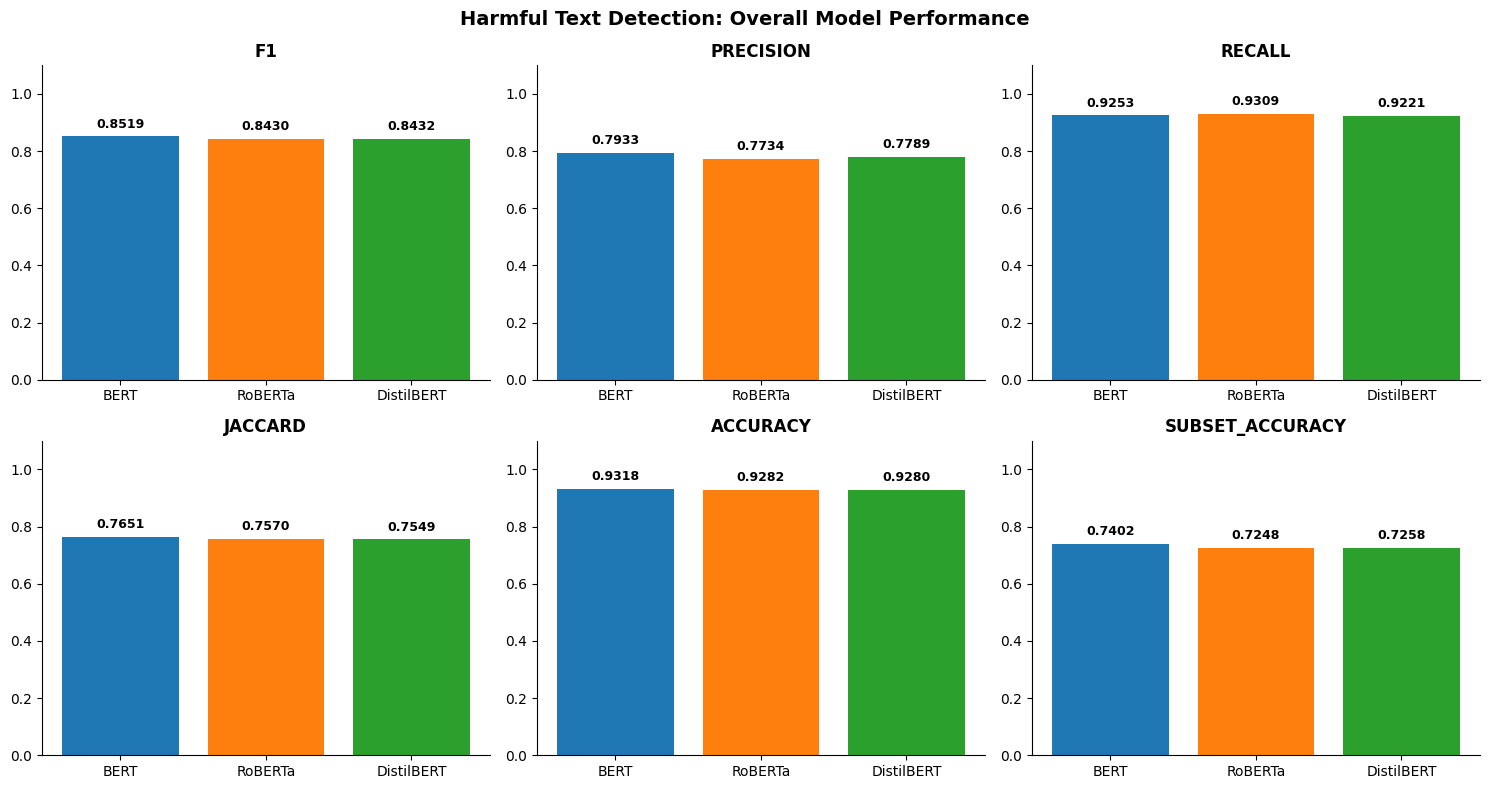

saved: comparison_overall_metrics.png


In [17]:
metrics_to_plot = ['f1', 'precision', 'recall', 'jaccard', 'accuracy', 'subset_accuracy']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Harmful Text Detection: Overall Model Performance', fontsize=14, fontweight='bold')
for ax, metric in zip(axes.flat, metrics_to_plot):
    vals = [results[m][metric] for m in models_list]
    bars = ax.bar(models_list, vals, color=colors)
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'comparison_overall_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: comparison_overall_metrics.png')

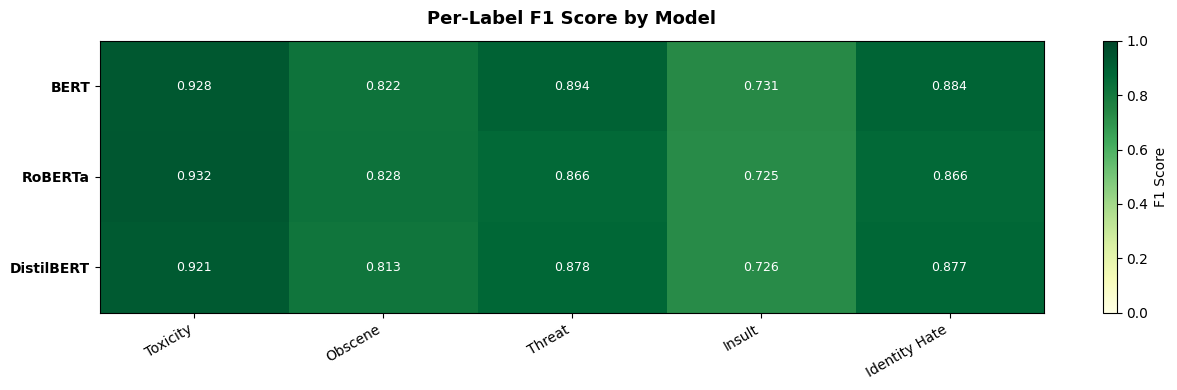

saved: comparison_per_label_heatmap.png


In [18]:
labels_order = list(LABEL_SCHEMA.keys())
heatmap_data = np.array([[per_label_results[m][lbl] for lbl in labels_order] for m in models_list])

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels_order)))
ax.set_xticklabels([l.replace('_', ' ').title() for l in labels_order], rotation=30, ha='right')
ax.set_yticks(range(len(models_list)))
ax.set_yticklabels(models_list, fontweight='bold')
for i in range(len(models_list)):
    for j in range(len(labels_order)):
        ax.text(j, i, f'{heatmap_data[i,j]:.3f}', ha='center', va='center',
                fontsize=9, color='black' if heatmap_data[i,j] < 0.7 else 'white')
plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Per-Label F1 Score by Model', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'comparison_per_label_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: comparison_per_label_heatmap.png')

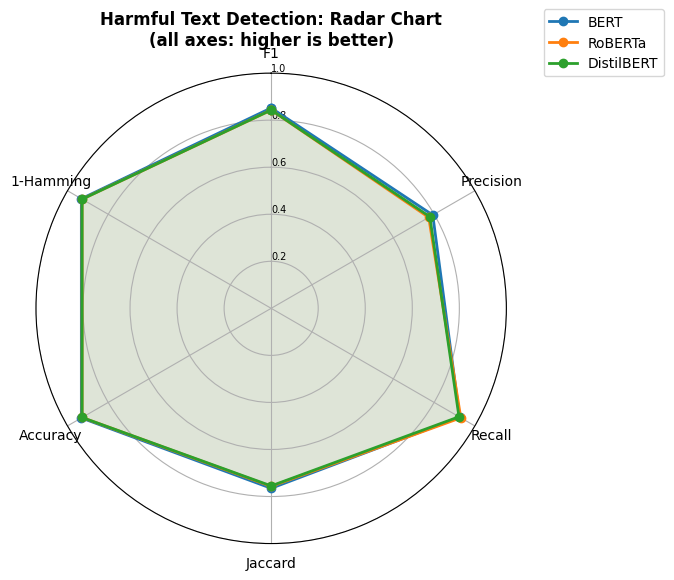

saved: comparison_radar.png


In [19]:
radar_metrics_display = ['F1', 'Precision', 'Recall', 'Jaccard', 'Accuracy', '1-Hamming']
N = len(radar_metrics_display)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)
plt.xticks(angles[:-1], radar_metrics_display, size=10)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=7)
ax.set_ylim(0, 1)

radar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for model, color in zip(models_list, radar_colors):
    vals_r = [
        results[model]['f1'], results[model]['precision'], results[model]['recall'],
        results[model]['jaccard'], results[model]['accuracy'],
        1 - results[model]['hamming_loss'],
    ] + [results[model]['f1']]
    ax.plot(angles, vals_r, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals_r, alpha=0.08, color=color)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Harmful Text Detection: Radar Chart\n(all axes: higher is better)',
             size=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'comparison_radar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: comparison_radar.png')

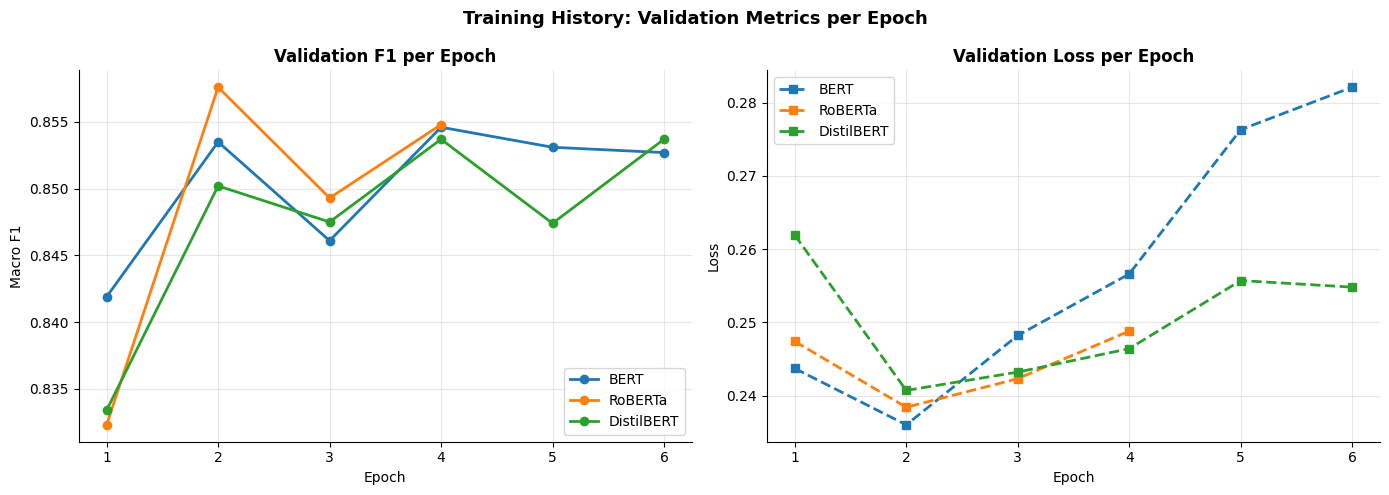

saved: comparison_training_history.png
best model: BERT  (f1 = 0.8519)
  f1                  : 0.8519
  precision           : 0.7933
  recall              : 0.9253
  jaccard             : 0.7651
  hamming_loss        : 0.0682
  accuracy            : 0.9318
  subset_accuracy     : 0.7402


In [20]:
histories = {
    'BERT':       bert_result['training_history'],
    'RoBERTa':    roberta_result['training_history'],
    'DistilBERT': distilbert_result['training_history'],
}
history_colors = {'BERT': '#1f77b4', 'RoBERTa': '#ff7f0e', 'DistilBERT': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History: Validation Metrics per Epoch', fontsize=13, fontweight='bold')
for model_name_h, hist in histories.items():
    epoch_keys = sorted([k for k in hist if isinstance(k, int)])
    if not epoch_keys:
        continue
    f1_vals   = [hist[e]['eval_f1'] for e in epoch_keys]
    loss_vals = [hist[e]['eval_loss'] for e in epoch_keys]
    color = history_colors[model_name_h]
    axes[0].plot(epoch_keys, f1_vals,   'o-',  label=model_name_h, color=color, linewidth=2)
    axes[1].plot(epoch_keys, loss_vals, 's--', label=model_name_h, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
    ['Validation F1 per Epoch', 'Validation Loss per Epoch'],
    ['Macro F1', 'Loss']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'comparison_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print('saved: comparison_training_history.png')

best_model = max(results, key=lambda m: results[m]['f1'])
print(f"best model: {best_model}  (f1 = {results[best_model]['f1']:.4f})")
for metric, val in results[best_model].items():
    print(f'  {metric:<20}: {val:.4f}')

## 8. save models

In [21]:
for model_key, (result, hf_name, folder_name) in all_results_map.items():
    save_path = os.path.join(models_dir, folder_name)
    os.makedirs(save_path, exist_ok=True)
    result['trainer'].save_model(save_path)
    result['tokenizer'].save_pretrained(save_path)
    with open(os.path.join(save_path, 'metrics.json'), 'w') as f:
        json_lib.dump(result['rich_metrics'], f, indent=2)
    joblib.dump({
        'model_name':      hf_name,
        'model_type':      model_key,
        'num_labels':      NUM_LABELS,
        'test_metrics':    result['test_metrics'],
        'label_schema':    LABEL_SCHEMA,
        'reverse_schema':  {str(k): v for k, v in REVERSE_LABEL_SCHEMA.items()},
        'best_thresholds': result['best_thresholds'],
    }, os.path.join(save_path, 'config.pkl'))
    with open(os.path.join(save_path, 'model_summary.txt'), 'w') as f:
        f.write(f'Harmful Text Detection Model: {hf_name}\n\n')
        f.write(f'Folder    : {folder_name}\n')
        f.write(f'HF ID     : {hf_name}\n')
        f.write(f'Num labels: {NUM_LABELS}\n')
        f.write(f'Labels    : {LABEL_NAMES}\n\n')
        f.write('Test Metrics (tuned thresholds):\n')
        for k, v in result['test_metrics'].items():
            f.write(f'  {k:<20}: {v:.4f}\n')
        f.write('\nPer-Label Detail:\n')
        for lbl, m in result['per_label_detail'].items():
            f.write(f'  {lbl:<20}: F1={m["f1"]:.4f}  P={m["precision"]:.4f}  R={m["recall"]:.4f}  t={m["threshold"]}\n')
        f.write('\nBest Thresholds:\n')
        for lbl, t in result['best_thresholds'].items():
            f.write(f'  {lbl:<20}: {t:.3f}\n')
        f.write(f'\nTrain time: {result["train_time_min"]:.1f} min\n')
    print(f'saved: {folder_name}/ (weights + metrics.json + config.pkl + model_summary.txt)')

if os.path.exists(dataset_csv_path):
    shutil.copy(dataset_csv_path, os.path.join(models_dir, 'harmful_text_augmented.csv'))
    print('copied: harmful_text_augmented.csv')

comparison_out = {}
for model_key, (result, hf_name, folder_name) in all_results_map.items():
    comparison_out[folder_name] = {
        'model_name':      hf_name,
        'test_metrics':    result['test_metrics'],
        'per_label_f1':    result['per_label_metrics'],
        'best_thresholds': result['best_thresholds'],
        'rich_metrics':    result['rich_metrics'],
    }
with open(os.path.join(models_dir, 'comparison_results.json'), 'w') as f:
    json_lib.dump(comparison_out, f, indent=2)
print('saved: comparison_results.json (3 models)')

print('models/ structure:')
for root, dirs, files in os.walk(models_dir):
    level = root.replace(models_dir, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = '  ' * (level + 1)
        for fname in sorted(files):
            fsize = os.path.getsize(os.path.join(root, fname))
            size_label = f'{fsize/1024:.1f} KB' if fsize < 1_048_576 else f'{fsize/1048576:.1f} MB'
            print(f'{subindent}{fname}  [{size_label}]')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved: bert/ (weights + metrics.json + config.pkl + model_summary.txt)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved: roberta/ (weights + metrics.json + config.pkl + model_summary.txt)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved: distilbert/ (weights + metrics.json + config.pkl + model_summary.txt)
copied: harmful_text_augmented.csv
saved: comparison_results.json (3 models)
models/ structure:
models/
  comparison_overall_metrics.png  [83.3 KB]
  comparison_per_label_heatmap.png  [64.4 KB]
  comparison_radar.png  [147.7 KB]
  comparison_results.json  [17.2 KB]
  comparison_training_history.png  [137.6 KB]
  harmful_text_augmented.csv  [11.1 MB]
  bert/
    config.json  [1.0 KB]
    config.pkl  [0.5 KB]
    metrics.json  [4.9 KB]
    model.safetensors  [417.7 MB]
    model_summary.txt  [0.9 KB]
    tokenizer.json  [695.0 KB]
    tokenizer_config.json  [0.3 KB]
    training_args.bin  [5.1 KB]
  roberta/
    config.json  [0.9 KB]
    config.pkl  [0.5 KB]
    metrics.json  [3.9 KB]
    model.safetensors  [475.5 MB]
    model_summary.txt  [0.9 KB]
    tokenizer.json  [3.4 MB]
    tokenizer_config.json  [0.4 KB]
    training_args.bin  [5.1 KB]
  distilbert/
    config.json  [0.9 KB]
    config.pkl  [0.6 KB]
   

## 9. inference

inference: 10 runs x 5 samples
loading: BERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  [CLEAN] This is a great product! Highly recommend.
    toxicity             0.0034  
    obscene              0.0023  
    threat               0.0028  
    insult               0.0020  
    identity_hate        0.0046  
  [FLAGGED] You are so stupid and worthless!
  labels: ['toxicity', 'obscene', 'insult']  risk: 0.9891
    toxicity             0.9802  ███████████████████
    obscene              0.6053  ████████████
    threat               0.0290  
    insult               0.9891  ███████████████████
    identity_hate        0.0142  
  [FLAGGED] I hate people from that country.
  labels: ['toxicity', 'insult', 'identity_hate']  risk: 0.9904
    toxicity             0.9827  ███████████████████
    obscene              0.0068  
    threat               0.0088  
    insult               0.2877  █████
    identity_hate        0.9904  ███████████████████
  [FLAGGED] I am going to hurt you, watch your back.
  labels: ['toxicity', 'threat']  risk: 0.9935
    toxicity             0.9696 

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  [CLEAN] This is a great product! Highly recommend.
    toxicity             0.0065  
    obscene              0.0052  
    threat               0.0065  
    insult               0.0060  
    identity_hate        0.0076  
  [FLAGGED] You are so stupid and worthless!
  labels: ['toxicity', 'obscene', 'insult']  risk: 0.973
    toxicity             0.9663  ███████████████████
    obscene              0.6686  █████████████
    threat               0.0114  
    insult               0.9730  ███████████████████
    identity_hate        0.0915  █
  [FLAGGED] I hate people from that country.
  labels: ['toxicity', 'identity_hate']  risk: 0.9727
    toxicity             0.9307  ██████████████████
    obscene              0.0067  
    threat               0.0983  █
    insult               0.0731  █
    identity_hate        0.9727  ███████████████████
  [FLAGGED] I am going to hurt you, watch your back.
  labels: ['toxicity', 'threat']  risk: 0.9935
    toxicity             0.9753  ████████████

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  [CLEAN] This is a great product! Highly recommend.
    toxicity             0.0062  
    obscene              0.0022  
    threat               0.0022  
    insult               0.0014  
    identity_hate        0.0014  
  [FLAGGED] You are so stupid and worthless!
  labels: ['toxicity', 'obscene', 'insult']  risk: 0.9839
    toxicity             0.9839  ███████████████████
    obscene              0.5873  ███████████
    threat               0.0162  
    insult               0.9836  ███████████████████
    identity_hate        0.0300  
  [FLAGGED] I hate people from that country.
  labels: ['toxicity', 'identity_hate']  risk: 0.8863
    toxicity             0.8863  █████████████████
    obscene              0.0018  
    threat               0.0034  
    insult               0.1054  ██
    identity_hate        0.8388  ████████████████
  [FLAGGED] I am going to hurt you, watch your back.
  labels: ['toxicity', 'threat']  risk: 0.9955
    toxicity             0.9852  ██████████████████

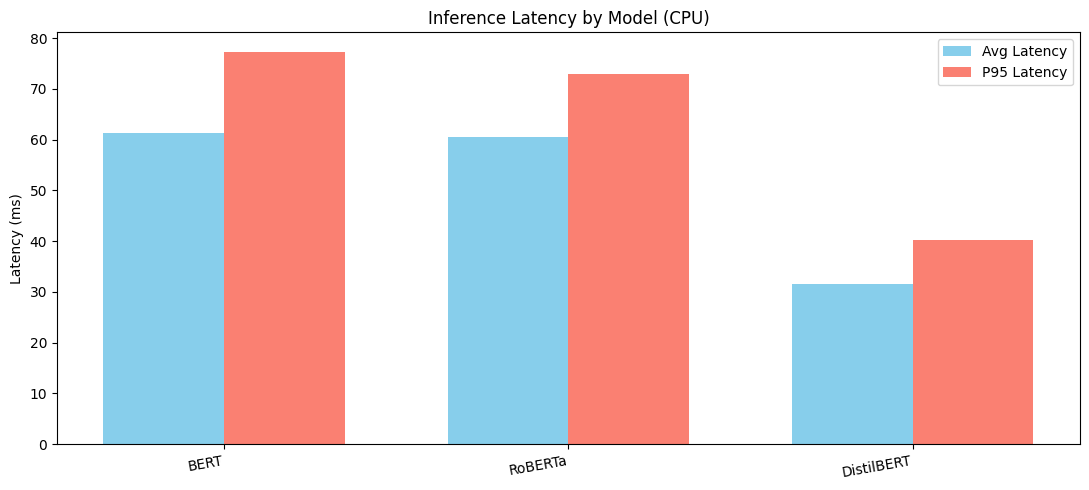

saved: models/comparison_inference_latency.png
accuracy vs speed
model                f1  precision   recall   avg ms
BERT             0.8519     0.7933   0.9253     61.2
RoBERTa          0.8430     0.7734   0.9309     60.6
DistilBERT       0.8432     0.7789   0.9221     31.6


In [22]:
timing_models = {
    'BERT':       os.path.join(models_dir, 'bert'),
    'RoBERTa':    os.path.join(models_dir, 'roberta'),
    'DistilBERT': os.path.join(models_dir, 'distilbert'),
}

timing_samples = [
    'This is a great product! Highly recommend.',
    'You are so stupid and worthless!',
    'I hate people from that country.',
    'I am going to hurt you, watch your back.',
    "Let's grab coffee sometime!",
]


def run_inference(text, model, tokenizer, config, max_length=128):
    model.eval()
    preprocessor = TextPreprocessor()
    cleaned = preprocessor.clean_text(text)
    inputs = tokenizer(cleaned, return_tensors='pt',
                       truncation=True, max_length=max_length, padding=True)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.sigmoid(logits).squeeze().tolist()
    thresholds = config.get('best_thresholds', {})
    reverse    = config['reverse_schema']
    scores  = {reverse[str(i)]: round(p, 4) for i, p in enumerate(probs)}
    flagged = [lbl for lbl, s in scores.items() if s >= thresholds.get(lbl, 0.5)]
    return {'is_flagged': len(flagged) > 0, 'labels': flagged,
            'scores': scores, 'risk_score': round(max(probs), 4)}


N_RUNS = 10
timing_summary = {}
loaded_models = []

print(f'inference: {N_RUNS} runs x {len(timing_samples)} samples')

for model_label, model_path in timing_models.items():
    print(f'loading: {model_label}')
    config    = joblib.load(os.path.join(model_path, 'config.pkl'))
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model_inf = AutoModelForSequenceClassification.from_pretrained(model_path)
    loaded_models.append((model_inf, tokenizer))

    for text in timing_samples:
        res = run_inference(text, model_inf, tokenizer, config)
        status = 'FLAGGED' if res['is_flagged'] else 'CLEAN'
        print(f'  [{status}] {text[:60]}')
        if res['is_flagged']:
            print(f'  labels: {res["labels"]}  risk: {res["risk_score"]}')
        for lbl, s in res['scores'].items():
            bar = chr(9608) * int(s * 20)
            print(f'    {lbl:<20} {s:.4f}  {bar}')

    run_inference('warmup', model_inf, tokenizer, config)
    times = []
    for _ in range(N_RUNS):
        for text in timing_samples:
            t0 = time.perf_counter()
            run_inference(text, model_inf, tokenizer, config)
            times.append((time.perf_counter() - t0) * 1000)
    timing_summary[model_label] = {
        'avg_ms': sum(times)/len(times), 'min_ms': min(times),
        'max_ms': max(times), 'p95_ms': float(np.percentile(times, 95))
    }
    t = timing_summary[model_label]
    print(f'  latency, avg: {t["avg_ms"]:.2f} ms, p95: {t["p95_ms"]:.2f} ms')

fig, ax = plt.subplots(figsize=(11, 5))
models_t = list(timing_summary.keys())
avgs = [timing_summary[m]['avg_ms'] for m in models_t]
p95s = [timing_summary[m]['p95_ms'] for m in models_t]
x = np.arange(len(models_t))
width = 0.35
ax.bar(x - width/2, avgs, width, label='Avg Latency', color='skyblue')
ax.bar(x + width/2, p95s, width, label='P95 Latency', color='salmon')
ax.set_ylabel('Latency (ms)')
ax.set_title('Inference Latency by Model (CPU)')
ax.set_xticks(x)
ax.set_xticklabels(models_t, rotation=10, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'comparison_inference_latency.png'), dpi=150)
plt.show()
print('saved: models/comparison_inference_latency.png')

print('accuracy vs speed')
print(f'{"model":<14} {"f1":>8} {"precision":>10} {"recall":>8} {"avg ms":>8}')
for m in models_list:
    r  = results[m]
    ms = timing_summary.get(m, {}).get('avg_ms', 0)
    print(f'{m:<14} {r["f1"]:>8.4f} {r["precision"]:>10.4f} {r["recall"]:>8.4f} {ms:>8.1f}')

## 10a. platform surface test, all models

bert, roberta and distilbert against examples from the four platform surfaces: job post, profile,
proposal, message. per-case results go to `platform_surface_test_results.json`.

In [23]:
print('platform surface test, all models')

# (surface, description, text, expected_toxic, expected_labels)
test_cases = [
    ('JOB POST', 'Clean job post',
     'We are looking for an experienced Python developer for a 3-month remote contract. Strong communication and testing skills required.',
     False, []),
    ('JOB POST', 'Insult toward applicants',
     'Only serious developers should apply. We are tired of dealing with incompetent freelancers who cannot follow a simple brief.',
     True,  ['insult', 'toxicity']),
    ('JOB POST', 'Discriminatory hiring',
     'This role is only open to local candidates. We do not hire foreign workers because they always create problems and miss deadlines.',
     True,  ['identity_hate', 'toxicity']),
    ('JOB POST', 'Threat to freelancer',
     'Meet every deadline without exception. Miss one and we will make sure your reputation on this platform is destroyed.',
     True,  ['threat', 'toxicity']),

    ('PROFILE', 'Clean profile bio',
     'Full-stack developer with 6 years of experience in React and Django. I specialise in building clean, maintainable code for startups.',
     False, []),
    ('PROFILE', 'Obscene + insult toward clients',
     'I am the best developer on this platform, period. If you are too cheap to pay my rate then you do not deserve quality work. I have destroyed the reputation of clients who tried to lowball me.',
     True,  ['insult', 'toxicity']),
    ('PROFILE', 'Threat toward clients',
     'I will destroy anyone who tries to lowball me or steal my work. The last client who screwed me over found out exactly what happens when you cross me.',
     True,  ['threat', 'toxicity']),

    ('PROPOSAL', 'Clean proposal',
     'I have carefully reviewed your project requirements and believe my three years of experience in this domain makes me an excellent fit.',
     False, []),
    ('PROPOSAL', 'Insult toward client brief',
     'Your project brief is so poorly written it is clear you have absolutely no idea what you actually need. Have you considered hiring a consultant first?',
     True,  ['insult', 'toxicity']),
    ('PROPOSAL', 'Threat if not selected',
     'You would be making a serious mistake not hiring me. The last client who rejected me found out the hard way why I was the right choice.',
     True,  ['threat', 'toxicity']),
    ('PROPOSAL', 'Identity hate toward client',
     'I see from your profile where you are from. I have worked with your type before and you people always find a way to disappoint your contractors.',
     True,  ['identity_hate', 'toxicity']),

    ('MESSAGE', 'Clean follow-up message',
     'Hi, just wanted to follow up on the deliverable we discussed. Are we still on track for the Friday deadline?',
     False, []),
    ('MESSAGE', 'Identity hate in message',
     'I am not paying someone like you. Your kind always scams people and then disappears. Go back to where you came from.',
     True,  ['identity_hate', 'toxicity']),
    ('MESSAGE', 'Obscene + insult, client venting',
     'You are an absolute piece of garbage. This is the worst work I have ever seen in my life, you should be ashamed to call yourself a developer.',
     True,  ['insult', 'obscene', 'toxicity']),
    ('MESSAGE', 'Threat, payment dispute',
     'Pay me the full amount by tomorrow or I will report you on every platform I can find and make sure everyone knows what kind of client you are.',
     True,  ['threat', 'toxicity']),
    ('MESSAGE', 'Escalated threat + insult',
     'I will ruin you. I will contact every client you have ever worked with and tell them what a fraud you are. Pay me now or this gets much worse.',
     True,  ['insult', 'threat', 'toxicity']),
]

model_order  = ['BERT', 'RoBERTa', 'DistilBERT']
model_configs = {m: joblib.load(os.path.join(timing_models[m], 'config.pkl')) for m in model_order}

all_run_data = {m: [] for m in model_order}

for model_name in model_order:
    idx = model_order.index(model_name)
    m_model, m_tok = loaded_models[idx]
    m_cfg = model_configs[model_name]

    print(f'\n  {model_name}')
    for surface, desc, text, exp_toxic, exp_labels in test_cases:
        res     = run_inference(text, m_model, m_tok, m_cfg)
        correct = (res['is_flagged'] == exp_toxic)
        all_run_data[model_name].append(dict(surface=surface, desc=desc, text=text,
                             exp_toxic=exp_toxic, exp_labels=exp_labels,
                             res=res, correct=correct))

    BAR = 20
    cur_surface = None
    for d in all_run_data[model_name]:
        if d['surface'] != cur_surface:
            cur_surface = d['surface']
            print(f'\n    {cur_surface}')

        verdict   = 'FLAGGED' if d['res']['is_flagged'] else 'CLEAN'
        sym       = '[PASS]' if d['correct'] else '[FAIL]'
        predicted = d['res']['labels']
        exp_lbl   = d['exp_labels']
        missed    = set(exp_lbl) - set(predicted)
        extra     = set(predicted) - set(exp_lbl)

        print(f'\n    {sym} {d["desc"]}  ->  {verdict}')
        print(f'    expected : {", ".join(exp_lbl) if exp_lbl else "none (clean)"}')
        print(f'    detected : {", ".join(predicted) if predicted else "none"}')
        if missed: print(f'    missed   : {", ".join(missed)}')
        if extra:  print(f'    extra    : {", ".join(extra)}')

    total   = len(all_run_data[model_name])
    correct = sum(1 for d in all_run_data[model_name] if d['correct'])
    fp = sum(1 for d in all_run_data[model_name] if not d['exp_toxic'] and d['res']['is_flagged'])
    fn = sum(1 for d in all_run_data[model_name] if d['exp_toxic'] and not d['res']['is_flagged'])
    print(f'\n  summary, model: {model_name}')
    print(f'    correctly classified : {correct} / {total}  ({correct/total*100:.0f}%)')
    print(f'    false positives      : {fp}')
    print(f'    false negatives      : {fn}')

# build per-question json across all models
json_cases = []
for case_idx, (surface, desc, text, exp_toxic, exp_labels) in enumerate(test_cases):
    entry = {
        'case_id': case_idx,
        'surface': surface,
        'description': desc,
        'text': text,
        'expected_toxic': exp_toxic,
        'expected_labels': exp_labels,
        'results': {},
    }
    for model_name in model_order:
        d = all_run_data[model_name][case_idx]
        entry['results'][model_name] = {
            'is_flagged': d['res']['is_flagged'],
            'detected_labels': d['res']['labels'],
            'scores': d['res']['scores'],
            'risk_score': d['res']['risk_score'],
            'correct': d['correct'],
        }
    json_cases.append(entry)

summary_by_model = {}
for model_name in model_order:
    data = all_run_data[model_name]
    total = len(data)
    correct = sum(1 for d in data if d['correct'])
    fp = sum(1 for d in data if not d['exp_toxic'] and d['res']['is_flagged'])
    fn = sum(1 for d in data if d['exp_toxic'] and not d['res']['is_flagged'])
    by_surface = {}
    for d in data:
        s = d['surface']
        by_surface.setdefault(s, {'correct': 0, 'total': 0})
        by_surface[s]['total']   += 1
        by_surface[s]['correct'] += int(d['correct'])
    summary_by_model[model_name] = {
        'total_cases': total,
        'correct': correct,
        'accuracy': round(correct / total, 4),
        'false_positives': fp,
        'false_negatives': fn,
        'by_surface': by_surface,
    }

platform_test_output = {
    'test_cases': json_cases,
    'summary': summary_by_model,
}

platform_json_path = os.path.join(models_dir, 'platform_surface_test_results.json')
with open(platform_json_path, 'w') as f:
    json_lib.dump(platform_test_output, f, indent=2)
print(f'\nsaved: {platform_json_path}')

print('\naccuracy comparison across models')
for model_name in model_order:
    s = summary_by_model[model_name]
    print(f'  {model_name:<12} {s["correct"]}/{s["total_cases"]} ({s["accuracy"]*100:.0f}%)  fp={s["false_positives"]}  fn={s["false_negatives"]}')

platform surface test, all models

  BERT

    JOB POST

    [PASS] Clean job post  ->  CLEAN
    expected : none (clean)
    detected : none

    [FAIL] Insult toward applicants  ->  CLEAN
    expected : insult, toxicity
    detected : none
    missed   : insult, toxicity

    [FAIL] Discriminatory hiring  ->  CLEAN
    expected : identity_hate, toxicity
    detected : none
    missed   : identity_hate, toxicity

    [PASS] Threat to freelancer  ->  FLAGGED
    expected : threat, toxicity
    detected : toxicity, threat

    PROFILE

    [PASS] Clean profile bio  ->  CLEAN
    expected : none (clean)
    detected : none

    [FAIL] Obscene + insult toward clients  ->  CLEAN
    expected : insult, toxicity
    detected : none
    missed   : insult, toxicity

    [PASS] Threat toward clients  ->  FLAGGED
    expected : threat, toxicity
    detected : toxicity, threat

    PROPOSAL

    [PASS] Clean proposal  ->  CLEAN
    expected : none (clean)
    detected : none

    [FAIL] Insult to

## 10b. adversarial evasion test, keyword vs ml

keyword matching is a closed lexicon, so spelling tricks, spacing and symbol substitution slip past it.

runs a simplified keyword scanner beside bert, roberta and distilbert on obfuscated harmful text, and
on clean idioms containing a trigger word. per-case results go to `adversarial_evasion_test_results.json`.

In [24]:
SIMPLE_KEYWORD_LEXICON = {
    'toxicity':      ['stupid', 'idiot', 'moron', 'dumb', 'loser', 'worthless', 'pathetic'],
    'obscene':       ['fuck', 'shit', 'bitch', 'asshole', 'bastard'],
    'threat':        ['kill you', 'i will kill', 'hurt you', 'destroy you', 'come after you'],
    'insult':        ['incompetent', 'garbage', 'useless', 'embarrassment'],
    'identity_hate': ['your kind', 'people like you', 'go back to', 'your country'],
}


def keyword_scan(text):
    normalized = text.lower().strip()
    detected = []
    for label, keywords in SIMPLE_KEYWORD_LEXICON.items():
        if any(kw in normalized for kw in keywords):
            detected.append(label)
    return {'is_flagged': len(detected) > 0, 'labels': detected}


# (description, text, expected_toxic, evasion_type)
adversarial_cases = [
    ('leetspeak threat',          'k1ll u if you dont pay me today',                         True,  'evasion'),
    ('leetspeak insult',          'ur such an id10t, cant believe i hired you',               True,  'evasion'),
    ('spaced-out obscenity',      'you are a c o m p l e t e  a s s h o l e',                 True,  'evasion'),
    ('symbol substitution',       'stop being such a $tupid @sshole about this',              True,  'evasion'),
    ('paraphrased threat',        'you will regret not paying me, i know where you work',     True,  'evasion'),
    ('synonym insult',            'your work is an absolute embarrassment, utterly inept',    True,  'evasion'),
    ('misspelled slur-adjacent',  'peple like yu allways screw over freelancers like this',   True,  'evasion'),
    ('idiom, deadline',           'this deadline is killing me, i need one more day please',  False, 'false_positive_check'),
    ('idiom, killer feature',     'that killer feature you built is going to impress clients', False, 'false_positive_check'),
    ('idiom, dying to see',       'i am dying to see the final designs, send them over',      False, 'false_positive_check'),
]

# keyword scanner has no per-model dependence, so run it once per case
kw_by_case = [keyword_scan(text) for _, text, _, _ in adversarial_cases]

print('adversarial evasion test, keyword vs ml, all models')

all_adv_data = {m: [] for m in model_order}

for model_name in model_order:
    idx = model_order.index(model_name)
    m_model, m_tok = loaded_models[idx]
    m_cfg = model_configs[model_name]

    print(f'\n  {model_name}')
    for (desc, text, exp_toxic, case_type), kw_res in zip(adversarial_cases, kw_by_case):
        ml_res = run_inference(text, m_model, m_tok, m_cfg)
        kw_correct = (kw_res['is_flagged'] == exp_toxic)
        ml_correct = (ml_res['is_flagged'] == exp_toxic)
        all_adv_data[model_name].append(dict(desc=desc, text=text, case_type=case_type,
                                              expected_toxic=exp_toxic,
                                              keyword=kw_res, ml=ml_res,
                                              kw_correct=kw_correct, ml_correct=ml_correct))

        print(f'\n    {desc}  [{case_type}]')
        print(f'    text     : "{text}"')
        print(f'    expected : {"flagged" if exp_toxic else "clean"}')
        print(f'    keyword  : {"flagged" if kw_res["is_flagged"] else "clean":<8} {"[correct]" if kw_correct else "[wrong]"}  labels={kw_res["labels"]}')
        print(f'    {model_name:<10}: {"flagged" if ml_res["is_flagged"] else "clean":<8} {"[correct]" if ml_correct else "[wrong]"}  labels={ml_res["labels"]}')

    evasion_cases  = [r for r in all_adv_data[model_name] if r['case_type'] == 'evasion']
    fp_check_cases = [r for r in all_adv_data[model_name] if r['case_type'] == 'false_positive_check']

    kw_caught_evasion = sum(1 for r in evasion_cases if r['kw_correct'])
    ml_caught_evasion = sum(1 for r in evasion_cases if r['ml_correct'])
    kw_fp_avoided     = sum(1 for r in fp_check_cases if r['kw_correct'])
    ml_fp_avoided     = sum(1 for r in fp_check_cases if r['ml_correct'])

    print(f'\n  summary, model: {model_name}')
    print(f'    evasion cases caught      : keyword {kw_caught_evasion}/{len(evasion_cases)}   ml {ml_caught_evasion}/{len(evasion_cases)}')
    print(f'    clean idioms not flagged  : keyword {kw_fp_avoided}/{len(fp_check_cases)}   ml {ml_fp_avoided}/{len(fp_check_cases)}')

# build per-case json across all models
json_cases = []
for case_idx, (desc, text, exp_toxic, case_type) in enumerate(adversarial_cases):
    kw_res = kw_by_case[case_idx]
    entry = {
        'case_id':          case_idx,
        'description':      desc,
        'text':             text,
        'case_type':        case_type,
        'expected_toxic':   exp_toxic,
        'keyword_flagged':  kw_res['is_flagged'],
        'keyword_labels':   kw_res['labels'],
        'keyword_correct':  (kw_res['is_flagged'] == exp_toxic),
        'models':           {},
    }
    for model_name in model_order:
        d = all_adv_data[model_name][case_idx]
        entry['models'][model_name] = {
            'is_flagged':      d['ml']['is_flagged'],
            'detected_labels': d['ml']['labels'],
            'scores':          d['ml']['scores'],
            'correct':         d['ml_correct'],
        }
    json_cases.append(entry)

evasion_total  = sum(1 for c in adversarial_cases if c[3] == 'evasion')
fp_check_total = sum(1 for c in adversarial_cases if c[3] == 'false_positive_check')
kw_caught_evasion_total = sum(1 for e in json_cases if e['case_type'] == 'evasion' and e['keyword_correct'])
kw_fp_avoided_total     = sum(1 for e in json_cases if e['case_type'] == 'false_positive_check' and e['keyword_correct'])

summary_by_model = {
    'keyword': {
        'evasion_caught':         {'correct': kw_caught_evasion_total, 'total': evasion_total},
        'false_positive_avoided': {'correct': kw_fp_avoided_total, 'total': fp_check_total},
    }
}
for model_name in model_order:
    data = all_adv_data[model_name]
    evasion_cases  = [r for r in data if r['case_type'] == 'evasion']
    fp_check_cases = [r for r in data if r['case_type'] == 'false_positive_check']
    summary_by_model[model_name] = {
        'evasion_caught':         {'correct': sum(1 for r in evasion_cases if r['ml_correct']), 'total': len(evasion_cases)},
        'false_positive_avoided': {'correct': sum(1 for r in fp_check_cases if r['ml_correct']), 'total': len(fp_check_cases)},
    }

adversarial_output = {
    'models_tested': model_order,
    'cases':   json_cases,
    'summary': summary_by_model,
}

adversarial_json_path = os.path.join(models_dir, 'adversarial_evasion_test_results.json')
with open(adversarial_json_path, 'w') as f:
    json_lib.dump(adversarial_output, f, indent=2)
print(f'\nsaved: {adversarial_json_path}')

print('\nevasion / false-positive comparison across keyword scanner and all models')
print(f'  {"keyword":<12} evasion {kw_caught_evasion_total}/{evasion_total}   clean-idioms {kw_fp_avoided_total}/{fp_check_total}')
for model_name in model_order:
    s = summary_by_model[model_name]
    print(f'  {model_name:<12} evasion {s["evasion_caught"]["correct"]}/{s["evasion_caught"]["total"]}   clean-idioms {s["false_positive_avoided"]["correct"]}/{s["false_positive_avoided"]["total"]}')


adversarial evasion test, keyword vs ml, all models

  BERT

    leetspeak threat  [evasion]
    text     : "k1ll u if you dont pay me today"
    expected : flagged
    keyword  : clean    [wrong]  labels=[]
    BERT      : flagged  [correct]  labels=['toxicity', 'obscene']

    leetspeak insult  [evasion]
    text     : "ur such an id10t, cant believe i hired you"
    expected : flagged
    keyword  : clean    [wrong]  labels=[]
    BERT      : flagged  [correct]  labels=['toxicity', 'insult']

    spaced-out obscenity  [evasion]
    text     : "you are a c o m p l e t e  a s s h o l e"
    expected : flagged
    keyword  : clean    [wrong]  labels=[]
    BERT      : flagged  [correct]  labels=['toxicity', 'obscene', 'insult', 'identity_hate']

    symbol substitution  [evasion]
    text     : "stop being such a $tupid @sshole about this"
    expected : flagged
    keyword  : clean    [wrong]  labels=[]
    BERT      : flagged  [correct]  labels=['toxicity', 'obscene', 'insult']

    

## 10c. chunking validation, truncation vs chunked inference

trained at `max_length=128`, so truncation drops everything past token 128. harmful content late in a
long text is scored blind. chunking splits into overlapping 128-token windows, scores each, and
max-pools per label.

the same long texts are scored both ways, harmful span placed past token 128. truncation should miss
it, chunking should catch it. if both catch, chunking earns nothing here.

In [25]:
def run_inference_chunked(text, model, tokenizer, config, max_length=128, stride=20):
    model.eval()
    preprocessor = TextPreprocessor()
    cleaned = preprocessor.clean_text(text)

    # native overflow chunking, windows of max_length with stride-token overlap
    enc = tokenizer(
        cleaned,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        return_tensors='pt',
        padding='max_length',
    )
    input_ids      = enc['input_ids']
    attention_mask = enc['attention_mask']
    num_chunks     = input_ids.shape[0]

    # all chunks in one batched forward pass
    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    probs = torch.sigmoid(logits).numpy()  # shape (num_chunks, num_labels)

    # max-pool across chunks per label, threshold after aggregation
    pooled = probs.max(axis=0)
    thresholds = config.get('best_thresholds', {})
    reverse    = config['reverse_schema']
    scores  = {reverse[str(i)]: round(float(p), 4) for i, p in enumerate(pooled)}
    flagged = [lbl for lbl, s in scores.items() if s >= thresholds.get(lbl, 0.5)]
    return {'is_flagged': len(flagged) > 0, 'labels': flagged,
            'scores': scores, 'risk_score': round(float(pooled.max()), 4),
            'num_chunks': num_chunks}


# neutral filler that carries no harmful signal, used to push the harmful span past token 128
FILLER = (
    'I have been working as a freelance developer for several years now and I take '
    'every project seriously from the first meeting to the final delivery. I always '
    'read the brief carefully, ask clarifying questions early, and set up a clear '
    'timeline so both sides know what to expect at each milestone. My typical stack '
    'covers web services, database design, and API integration, and I document '
    'everything so the handover is smooth. I value clear communication and I try to '
    'reply to messages within a business day so nothing stalls on my side. '
) * 3  # ~230 words of harmless text before anything harmful appears

# (description, harmful tail placed AFTER the filler, expected label)
chunk_cases = [
    ('threat, late in text',
     FILLER + ' Pay me the full amount by tomorrow or I will make sure your reputation on every platform is destroyed and everyone knows what kind of client you are.',
     'threat'),
    ('insult, late in text',
     FILLER + ' Honestly your brief is garbage and you are clearly incompetent, you have no idea what you actually need and it shows in everything you write.',
     'insult'),
    ('identity_hate, late in text',
     FILLER + ' I see where you are from and people like you always try to scam contractors, your kind never pays what was agreed and then disappears.',
     'identity_hate'),
    ('clean, long text',
     FILLER + ' Looking forward to hearing back and discussing the details whenever works for you, happy to jump on a quick call this week.',
     None),
]

chunk_eval_by_model = {}

for model_name in model_order:
    idx = model_order.index(model_name)
    cm_model, cm_tok = loaded_models[idx]
    cm_cfg = model_configs[model_name]

    print(f'\nchunking validation, model: {model_name}')
    rows = []
    for desc, text, exp_label in chunk_cases:
        word_count = len(text.split())
        trunc = run_inference(text, cm_model, cm_tok, cm_cfg)               # max_length=128 default
        chunk = run_inference_chunked(text, cm_model, cm_tok, cm_cfg)

        exp_toxic = exp_label is not None
        trunc_correct = (trunc['is_flagged'] == exp_toxic)
        chunk_correct = (chunk['is_flagged'] == exp_toxic)

        rows.append(dict(desc=desc, words=word_count, exp_label=exp_label,
                         trunc=trunc, chunk=chunk,
                         trunc_correct=trunc_correct, chunk_correct=chunk_correct))

        print(f'  {desc}  ({word_count} words)')
        tag = f'expected {exp_label} past token 128' if exp_label else 'expected clean'
        print(f'    {tag}')
        print(f'    truncation-128 : {"flagged" if trunc["is_flagged"] else "clean":<8} labels={trunc["labels"]}  {"[correct]" if trunc_correct else "[MISS]"}')
        print(f'    chunking       : {"flagged" if chunk["is_flagged"] else "clean":<8} labels={chunk["labels"]}  chunks={chunk["num_chunks"]}  {"[correct]" if chunk_correct else "[MISS]"}')
        if exp_label:
            print(f'    score on {exp_label:<14}: truncation {trunc["scores"].get(exp_label, 0):.4f}  ->  chunking {chunk["scores"].get(exp_label, 0):.4f}')

    chunk_eval_by_model[model_name] = rows

# summary across all models
print(f'\nsummary, harmful span placed past token 128')
print(f'  {"model":<12} {"trunc caught":>13} {"chunk caught":>13} {"clean ok":>10} {"delta":>7}')
summary_by_model = {}
for model_name in model_order:
    rows = chunk_eval_by_model[model_name]
    toxic_cases = [c for c in rows if c['exp_label'] is not None]
    clean_cases = [c for c in rows if c['exp_label'] is None]
    trunc_caught = sum(1 for c in toxic_cases if c['trunc_correct'])
    chunk_caught = sum(1 for c in toxic_cases if c['chunk_correct'])
    chunk_clean_ok = sum(1 for c in clean_cases if c['chunk_correct'])
    delta = chunk_caught - trunc_caught
    summary_by_model[model_name] = {
        'harmful_caught_truncation': trunc_caught,
        'harmful_caught_chunking': chunk_caught,
        'harmful_total': len(toxic_cases),
        'chunking_clean_correct': chunk_clean_ok,
        'clean_total': len(clean_cases),
        'delta_caught_by_chunking_only': delta,
    }
    print(f'  {model_name:<12} {f"{trunc_caught}/{len(toxic_cases)}":>13} {f"{chunk_caught}/{len(toxic_cases)}":>13} {f"{chunk_clean_ok}/{len(clean_cases)}":>10} {delta:>+7}')

chunk_output = {
    'method': 'truncation max_length=128 vs overlapping 128-token chunks, stride=20, max-pool per label',
    'models': {
        model_name: {
            'summary': summary_by_model[model_name],
            'cases': [
                {
                    'description': c['desc'],
                    'word_count': c['words'],
                    'expected_label_past_128': c['exp_label'],
                    'truncation_flagged': c['trunc']['is_flagged'],
                    'truncation_labels': c['trunc']['labels'],
                    'truncation_scores': c['trunc']['scores'],
                    'truncation_correct': c['trunc_correct'],
                    'chunking_flagged': c['chunk']['is_flagged'],
                    'chunking_labels': c['chunk']['labels'],
                    'chunking_scores': c['chunk']['scores'],
                    'chunking_num_chunks': c['chunk']['num_chunks'],
                    'chunking_correct': c['chunk_correct'],
                }
                for c in chunk_eval_by_model[model_name]
            ],
        }
        for model_name in model_order
    },
}

chunk_json_path = os.path.join(models_dir, 'chunking_validation_results.json')
with open(chunk_json_path, 'w') as f:
    json_lib.dump(chunk_output, f, indent=2)
print(f'\nsaved: {chunk_json_path}')


chunking validation, model: BERT
  threat, late in text  (307 words)
    expected threat past token 128
    truncation-128 : clean    labels=[]  [MISS]
    chunking       : flagged  labels=['threat']  chunks=4  [correct]
    score on threat        : truncation 0.0038  ->  chunking 0.6146
  insult, late in text  (304 words)
    expected insult past token 128
    truncation-128 : clean    labels=[]  [MISS]
    chunking       : flagged  labels=['toxicity', 'insult']  chunks=4  [correct]
    score on insult        : truncation 0.0030  ->  chunking 0.9096
  identity_hate, late in text  (304 words)
    expected identity_hate past token 128
    truncation-128 : clean    labels=[]  [MISS]
    chunking       : flagged  labels=['toxicity']  chunks=4  [correct]
    score on identity_hate : truncation 0.0021  ->  chunking 0.0313
  clean, long text  (301 words)
    expected clean
    truncation-128 : clean    labels=[]  [correct]
    chunking       : clean    labels=[]  chunks=3  [correct]

chunki

## 11. threshold sweep and profiles

per-label cut-offs, chosen on val, scored on test.

- `recall` argmax f-beta(1.5)
- `balanced` argmax f1
- `precision` lowest threshold reaching the floor

writes `threshold_sweep.json`, `threshold_profiles.json`, and adds `threshold_profiles` to config.pkl.

sweep device: cuda

=== bert ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  recall profile matches stored best_thresholds

  cut-offs chosen on val:
  label              recall  balanced  precision
  toxicity             0.50      0.58       0.88
  obscene              0.38      0.60       0.88
  threat               0.58      0.84       0.88
  insult               0.28      0.70       0.88
  identity_hate        0.38      0.72       0.88

  test-set metrics per profile:
  profile       f1_macro  precision   recall  hamming  subset_acc
  recall          0.8519     0.7933   0.9253   0.0682      0.7402
  balanced        0.8557     0.8348   0.8781   0.0610      0.7584
  precision       0.8386     0.8734   0.8077   0.0654      0.7479

=== roberta ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  recall profile matches stored best_thresholds

  cut-offs chosen on val:
  label              recall  balanced  precision
  toxicity             0.26      0.54       0.84
  obscene              0.52      0.58       0.88
  threat               0.12      0.76       0.88
  insult               0.30      0.50       0.88
  identity_hate        0.32      0.70       0.88

  test-set metrics per profile:
  profile       f1_macro  precision   recall  hamming  subset_acc
  recall          0.8430     0.7734   0.9309   0.0718      0.7248
  balanced        0.8544     0.8296   0.8822   0.0625      0.7562
  precision       0.8061     0.9024   0.7395   0.0758      0.7125

=== distilbert ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  recall profile matches stored best_thresholds

  cut-offs chosen on val:
  label              recall  balanced  precision
  toxicity             0.22      0.30       0.88
  obscene              0.40      0.48       0.88
  threat               0.44      0.60       0.88
  insult               0.40      0.56       0.88
  identity_hate        0.36      0.70       0.88

  test-set metrics per profile:
  profile       f1_macro  precision   recall  hamming  subset_acc
  recall          0.8432     0.7789   0.9221   0.0720      0.7258
  balanced        0.8489     0.8052   0.8995   0.0669      0.7400
  precision       0.8306     0.8762   0.7905   0.0699      0.7260

saved: threshold_sweep.json, threshold_profiles.json, config.pkl updated per model


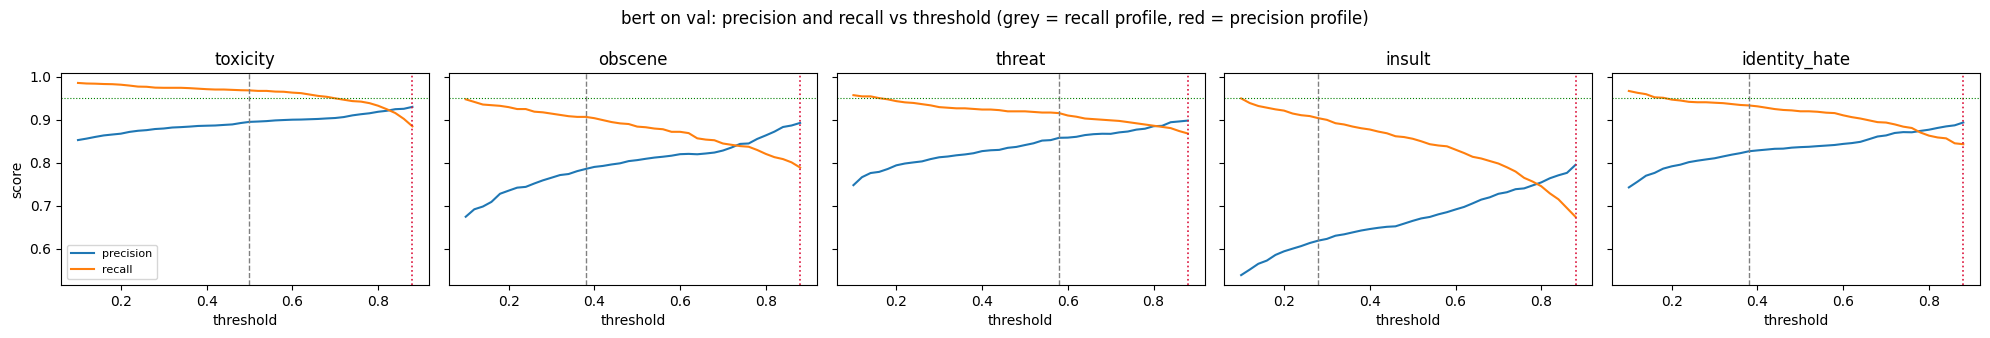

In [26]:
# threshold sweep -> profiles -> test metrics
PRECISION_FLOOR = 0.95              # precision profile takes the lowest threshold reaching this
GRID = np.arange(0.10, 0.90, 0.02)  # same grid the training-time search uses

SWEEP_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('sweep device:', SWEEP_DEVICE)

def load_for_eval(model_path):
    # single device, so results match trainer.predict
    tok = AutoTokenizer.from_pretrained(model_path)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_path).to(SWEEP_DEVICE)
    mdl.eval()
    return tok, mdl


def probabilities(mdl, tok, df, max_length=128, batch_size=64):
    # inference only, same cleaning and truncation as training
    pp = TextPreprocessor()
    texts = [pp.clean_text(t) for t in df['text'].tolist()]
    chunks = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tok(texts[i:i + batch_size], truncation=True, padding=True,
                      max_length=max_length, return_tensors='pt')
            enc = {k: v.to(SWEEP_DEVICE) for k, v in enc.items()}
            chunks.append(torch.sigmoid(mdl(**enc).logits).cpu())
    return torch.cat(chunks).numpy(), np.array(df['labels'].tolist(), dtype=int)


def full_sweep(probs, labels):
    # every grid point, every label. tp/fp/fn kept so another rule can reuse this
    sweep = {}
    for i, label in enumerate(LABEL_NAMES):
        y, rows = labels[:, i], []
        for t in GRID:
            p = (probs[:, i] > t).astype(int)
            rows.append({
                'threshold':  round(float(t), 3),
                'precision':  round(float(precision_score(y, p, zero_division=0)), 4),
                'recall':     round(float(recall_score(y, p, zero_division=0)), 4),
                'f1':         round(float(f1_score(y, p, zero_division=0)), 4),
                'fbeta_1.5':  round(float(fbeta_score(y, p, beta=1.5, zero_division=0)), 4),
                'fbeta_0.5':  round(float(fbeta_score(y, p, beta=0.5, zero_division=0)), 4),
                'tp': int(((p == 1) & (y == 1)).sum()),
                'fp': int(((p == 1) & (y == 0)).sum()),
                'fn': int(((p == 0) & (y == 1)).sum()),
            })
        sweep[label] = rows
    return sweep


def derive_profiles(sweep, precision_floor=PRECISION_FLOOR):
    # three cut-off sets off the same sweep, chosen per label
    profiles = {'recall': {}, 'balanced': {}, 'precision': {}}
    rationale = {}
    for label, rows in sweep.items():
        recall_pt   = max(rows, key=lambda r: r['fbeta_1.5'])
        balanced_pt = max(rows, key=lambda r: r['f1'])
        meets = [r for r in rows if r['precision'] >= precision_floor]
        # lowest threshold meeting the floor, else the most precise point
        precision_pt = min(meets, key=lambda r: r['threshold']) if meets else max(rows, key=lambda r: r['precision'])
        profiles['recall'][label]    = recall_pt['threshold']
        profiles['balanced'][label]  = balanced_pt['threshold']
        profiles['precision'][label] = precision_pt['threshold']
        rationale[label] = {
            'recall':              {k: recall_pt[k]    for k in ('threshold', 'precision', 'recall', 'f1')},
            'balanced':            {k: balanced_pt[k]  for k in ('threshold', 'precision', 'recall', 'f1')},
            'precision':           {k: precision_pt[k] for k in ('threshold', 'precision', 'recall', 'f1')},
            'precision_floor_met': bool(meets),
        }
    return profiles, rationale


def evaluate_profile(probs, labels, thresholds):
    # score a cut-off set on a held-out split
    preds = np.zeros_like(probs, dtype=int)
    for i, label in enumerate(LABEL_NAMES):
        preds[:, i] = (probs[:, i] >= thresholds[label]).astype(int)
    per_label = {
        label: {
            'threshold': thresholds[label],
            'f1':        round(float(f1_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'precision': round(float(precision_score(labels[:, i], preds[:, i], zero_division=0)), 4),
            'recall':    round(float(recall_score(labels[:, i], preds[:, i], zero_division=0)), 4),
        }
        for i, label in enumerate(LABEL_NAMES)
    }
    return {
        'f1_macro':        round(float(f1_score(labels, preds, average='macro', zero_division=0)), 4),
        'precision_macro': round(float(precision_score(labels, preds, average='macro', zero_division=0)), 4),
        'recall_macro':    round(float(recall_score(labels, preds, average='macro', zero_division=0)), 4),
        'hamming_loss':    round(float(hamming_loss(labels, preds)), 4),
        'subset_accuracy': round(float((preds == labels).all(axis=1).mean()), 4),
        'per_label':       per_label,
    }


sweep_by_model, profiles_by_model = {}, {}

for model_key, (result, _, folder_name) in all_results_map.items():
    model_path = os.path.join(models_dir, folder_name)
    print(f'\n=== {model_key} ===')
    tok, mdl = load_for_eval(model_path)

    # choose on val
    val_probs, val_labels = probabilities(mdl, tok, val_df)
    sweep = full_sweep(val_probs, val_labels)
    profiles, rationale = derive_profiles(sweep)

    # report on test
    test_probs, test_labels = probabilities(mdl, tok, test_df)
    test_by_profile = {name: evaluate_profile(test_probs, test_labels, thr)
                       for name, thr in profiles.items()}

    del mdl
    if SWEEP_DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    sweep_by_model[model_key] = sweep
    profiles_by_model[model_key] = {
        'profiles': profiles, 'rationale_on_val': rationale,
        'test_metrics_by_profile': test_by_profile,
        'precision_floor': PRECISION_FLOOR,
        'tuned_on': 'val', 'reported_on': 'test',
        'grid': [round(float(t), 3) for t in GRID],
    }

    # recall profile should reproduce best_thresholds in config.pkl
    stored = result['best_thresholds']
    drift = {l: (stored[l], profiles['recall'][l])
             for l in LABEL_NAMES if abs(stored[l] - profiles['recall'][l]) > 1e-6}
    print('  recall profile matches stored best_thresholds' if not drift else f'  warning, drift: {drift}')

    # append profiles, keep best_thresholds
    cfg_path = os.path.join(model_path, 'config.pkl')
    cfg = joblib.load(cfg_path)
    cfg['threshold_profiles'] = profiles
    cfg['precision_floor'] = PRECISION_FLOOR
    joblib.dump(cfg, cfg_path)

    print('\n  cut-offs chosen on val:')
    print(f"  {'label':<16}{'recall':>9}{'balanced':>10}{'precision':>11}")
    for l in LABEL_NAMES:
        print(f"  {l:<16}{profiles['recall'][l]:>9.2f}{profiles['balanced'][l]:>10.2f}{profiles['precision'][l]:>11.2f}")

    print('\n  test-set metrics per profile:')
    print(f"  {'profile':<12}{'f1_macro':>10}{'precision':>11}{'recall':>9}{'hamming':>9}{'subset_acc':>12}")
    for name, m in test_by_profile.items():
        print(f"  {name:<12}{m['f1_macro']:>10.4f}{m['precision_macro']:>11.4f}"
              f"{m['recall_macro']:>9.4f}{m['hamming_loss']:>9.4f}{m['subset_accuracy']:>12.4f}")

with open(os.path.join(models_dir, 'threshold_sweep.json'), 'w') as f:
    json_lib.dump(sweep_by_model, f, indent=2)
with open(os.path.join(models_dir, 'threshold_profiles.json'), 'w') as f:
    json_lib.dump(profiles_by_model, f, indent=2)
print('\nsaved: threshold_sweep.json, threshold_profiles.json, config.pkl updated per model')

# precision/recall vs threshold, best model
_KEY_BY_DISPLAY = {'BERT': 'bert', 'RoBERTa': 'roberta', 'DistilBERT': 'distilbert'}
_best = _KEY_BY_DISPLAY[best_model]
_sweep = sweep_by_model[_best]
_, axes = plt.subplots(1, len(LABEL_NAMES), figsize=(4 * len(LABEL_NAMES), 3.4), sharey=True)
for ax, label in zip(np.atleast_1d(axes), LABEL_NAMES):
    rows = _sweep[label]
    ts = [r['threshold'] for r in rows]
    ax.plot(ts, [r['precision'] for r in rows], label='precision')
    ax.plot(ts, [r['recall'] for r in rows], label='recall')
    ax.axvline(profiles_by_model[_best]['profiles']['recall'][label], ls='--', c='gray', lw=1)
    ax.axvline(profiles_by_model[_best]['profiles']['precision'][label], ls=':', c='crimson', lw=1.2)
    ax.axhline(PRECISION_FLOOR, ls=':', c='green', lw=0.8)
    ax.set_title(label)
    ax.set_xlabel('threshold')
np.atleast_1d(axes)[0].set_ylabel('score')
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.suptitle(f'{_best} on val: precision and recall vs threshold (grey = recall profile, red = precision profile)')
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'threshold_sweep_curves.png'), dpi=150)
plt.show()


## 12. inference parity tests

- t1 training and inference clean text identically
- t2 chunking sees harm past token 128
- t3 obfuscated text is not blanked before scoring
- t4 keyword fallback ignores legitimate titles
- t5 the precision profile clears short-field false positives

t1 and t4 run once. t2, t3 and t5 run per model.

In [27]:
# chunked inference path, checked against every model
import re as _re

def infer_clean_text(text):
    # must match training cleaning, see t1
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = _re.sub(r'https?://\S+', '', text)
    text = _re.sub(r'www\.\S+', '', text)
    text = _re.sub(r'<[^>]+>', '', text)
    # keep the word, drop the sigil
    text = _re.sub(r'@(\w+)', r'\1', text)
    text = _re.sub(r'#(\w+)', r'\1', text)
    text = _re.sub(r'[^\w\s.,!?-]', '', text)
    return _re.sub(r'\s+', ' ', text).strip()


def chunked_predict(texts, model, tokenizer, thresholds, max_length=128, stride=20):
    # chunk, max-pool, per-label cut-offs
    cleaned = [infer_clean_text(t) for t in texts]
    results = [{'labels': [], 'scores': {l: 0.0 for l in LABEL_NAMES},
                'is_harmful': False, 'cleaned': c} for c in cleaned]
    # empty after cleaning, never scanned
    keep = [i for i, c in enumerate(cleaned) if c]
    if not keep:
        return results

    enc = tokenizer([cleaned[i] for i in keep], max_length=max_length, stride=stride,
                    truncation=True, padding=True, return_overflowing_tokens=True,
                    return_tensors='pt')
    mapping = enc.pop('overflow_to_sample_mapping').tolist()
    _dev = next(model.parameters()).device   # inputs follow the model
    enc = {k: v.to(_dev) for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.sigmoid(model(**enc).logits).cpu().numpy()

    # max-pool chunks back onto their text
    pooled = {}
    for row, sample_idx in zip(probs, mapping):
        idx = keep[sample_idx]
        pooled[idx] = list(row) if idx not in pooled else [max(a, b) for a, b in zip(pooled[idx], row)]

    for idx, row in pooled.items():
        scores = {l: round(float(p), 4) for l, p in zip(LABEL_NAMES, row)}
        flagged = [l for l in LABEL_NAMES if scores[l] >= thresholds.get(l, 0.5)]
        results[idx] = {'labels': flagged, 'scores': scores,
                        'is_harmful': bool(flagged), 'cleaned': cleaned[idx]}
    return results


MODELS = [('BERT', 'bert'), ('RoBERTa', 'roberta'), ('DistilBERT', 'distilbert')]


def load_model_for(folder):
    path = os.path.join(models_dir, folder)
    cfg = joblib.load(os.path.join(path, 'config.pkl'))
    tok = AutoTokenizer.from_pretrained(path)
    mdl = AutoModelForSequenceClassification.from_pretrained(path)
    mdl.eval()
    return cfg, tok, mdl


checks = []
def check(name, passed, detail='', model=None):
    checks.append({'model': model, 'test': name, 'passed': bool(passed), 'detail': detail})
    tag = f'[{model}] ' if model else ''
    print(f"  [{'pass' if passed else 'fail'}] {tag}{name}" + (f": {detail}" if detail else ''))


# t1 and t4 use no weights, run once
print('t1. training and inference clean text identically')
_pp = TextPreprocessor()
_battery = ['visit www.spam.com @troll #hate', 'you are a $tupid @sshole', '  spaced   out  ',
            '<b>html</b> tags', 'k1ll u', '@Drmies: thanks', 'f@ck you', 'normal professional text.']
_drift = [s for s in _battery if _pp.clean_text(s) != infer_clean_text(s)]
check('training clean_text == inference clean_text', not _drift, f'drift on {_drift}' if _drift else '')
# mention keeps its word
_mention = infer_clean_text('@Drmies: thanks for the edit')
check("mention '@Drmies' degrades to a plain name", _mention.startswith('Drmies'), f'-> {_mention!r}')

print('\nt4. keyword fallback ignores legitimate professional titles')
# word boundaries. '*' is a stem. topic words are not keywords
_kw = {'toxic': ['dumb', 'idiot', 'moron'],
       'obscene': ['prostitut*'],
       'identity_hate': ['go back to your country', 'your kind always']}

def _kw_pattern(k):
    if k.endswith('*'):
        return _re.compile(r'\b' + _re.escape(k[:-1]) + r'\w*')
    return _re.compile(r'\b' + _re.escape(k) + r'\b')

_kw_pat = {lab: [_kw_pattern(k) for k in ks] for lab, ks in _kw.items()}

def _keyword_flag(t):
    n = t.lower()
    return [lab for lab, ps in _kw_pat.items() if any(p.search(n) for p in ps)]

_legit = ['Dumbbell Training', 'Anti-Racism Training Facilitator',
          'Historian specializing in Nazi Germany', 'thanks for your kindness']
_kw_fps = {t: _keyword_flag(t) for t in _legit if _keyword_flag(t)}
check('keyword scan leaves legit titles clean', not _kw_fps, f'matches: {_kw_fps}')
# also pin the true positives
_kw_tp = {t: _keyword_flag(t) for t in ['you are an idiot', 'go back to your country']}
check('keyword scan still catches real hits', all(_kw_tp.values()), f'{_kw_tp}')

# t2, t3, t5 use weights, run per model
_filler = 'we discussed the project timeline and deliverables in detail. ' * 30
_late = _filler + ' you are a worthless idiot and i will hurt you.'
_legit_titles = ['Dumbbell Training', 'Suicide Prevention Counselor', 'Penetration Testing',
                 'Anti-Racism Training Facilitator', 'Senior Software Engineer']
_harmful_short = ['kill yourself', 'you are a stupid idiot', 'I will find you and hurt you']

parity_by_model = {}
for _label, _folder in MODELS:
    if not os.path.isdir(os.path.join(models_dir, _folder)):
        continue
    _cfg_m, _tok_m, _mdl_m = load_model_for(_folder)
    _recall_t = _cfg_m['threshold_profiles']['recall']
    _precision_t = _cfg_m['threshold_profiles']['precision']
    print(f'\n--- {_label} ---')

    # t2
    _enc = _tok_m(infer_clean_text(_late), truncation=True, max_length=128, return_tensors='pt')
    with torch.no_grad():
        _ts = torch.sigmoid(_mdl_m(**_enc).logits).numpy()[0]
    _trunc = any(s >= _recall_t[l] for l, s in zip(LABEL_NAMES, _ts))
    _chunk = chunked_predict([_late], _mdl_m, _tok_m, _recall_t)[0]['is_harmful']
    check('t2 chunking flags late harm that truncation misses', _chunk and not _trunc,
          f'truncation={_trunc}, chunked={_chunk}', _label)

    # t3
    for _t in ['@sshole', 'you are such an @sshole', 'f@ck you']:
        _r = chunked_predict([_t], _mdl_m, _tok_m, _recall_t)[0]
        check(f't3 {_t!r} survives cleaning', _r['cleaned'] != '',
              f"-> {_r['cleaned']!r} | flagged={_r['is_harmful']} {_r['labels']}", _label)

    # t5
    _rr = chunked_predict(_legit_titles, _mdl_m, _tok_m, _recall_t)
    _pp2 = chunked_predict(_legit_titles, _mdl_m, _tok_m, _precision_t)
    _ph = chunked_predict(_harmful_short, _mdl_m, _tok_m, _precision_t)
    _fp_recall = [t for t, x in zip(_legit_titles, _rr) if x['is_harmful']]
    _fp_prec = [t for t, x in zip(_legit_titles, _pp2) if x['is_harmful']]
    _fn_prec = [t for t, x in zip(_harmful_short, _ph) if not x['is_harmful']]
    print(f'  recall profile blocks   : {_fp_recall}')
    print(f'  precision profile blocks: {_fp_prec}')
    print(f'  precision profile misses: {_fn_prec}')
    check('t5 precision profile: no legit title blocked, no harmful short string missed',
          not _fp_prec and not _fn_prec, '', _label)

    parity_by_model[_label] = {'fp_recall_profile': _fp_recall, 'fp_precision_profile': _fp_prec,
                               'fn_precision_profile': _fn_prec,
                               'chunking_beats_truncation': bool(_chunk and not _trunc)}
    del _mdl_m

with open(os.path.join(models_dir, 'inference_parity_results.json'), 'w') as f:
    json_lib.dump({'checks': checks, 'per_model': parity_by_model, 'known_failures': []}, f, indent=2)
_failed = [f"{c['model'] or 'shared'}: {c['test']}" for c in checks if not c['passed']]
print(f"\n{sum(c['passed'] for c in checks)}/{len(checks)} passed. failing: {_failed}")
print('saved: inference_parity_results.json')


t1. training and inference clean text identically
  [pass] training clean_text == inference clean_text
  [pass] mention '@Drmies' degrades to a plain name: -> 'Drmies thanks for the edit'

t4. keyword fallback ignores legitimate professional titles
  [pass] keyword scan leaves legit titles clean: matches: {}
  [pass] keyword scan still catches real hits: {'you are an idiot': ['toxic'], 'go back to your country': ['identity_hate']}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- BERT ---
  [pass] [BERT] t2 chunking flags late harm that truncation misses: truncation=False, chunked=True
  [pass] [BERT] t3 '@sshole' survives cleaning: -> 'sshole' | flagged=True ['toxicity']
  [pass] [BERT] t3 'you are such an @sshole' survives cleaning: -> 'you are such an sshole' | flagged=True ['toxicity', 'obscene', 'insult']
  [pass] [BERT] t3 'f@ck you' survives cleaning: -> 'fck you' | flagged=True ['toxicity', 'obscene', 'insult']
  recall profile blocks   : ['Dumbbell Training', 'Suicide Prevention Counselor']
  precision profile blocks: ['Dumbbell Training', 'Suicide Prevention Counselor']
  precision profile misses: []
  [fail] [BERT] t5 precision profile: no legit title blocked, no harmful short string missed


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- RoBERTa ---
  [pass] [RoBERTa] t2 chunking flags late harm that truncation misses: truncation=False, chunked=True
  [pass] [RoBERTa] t3 '@sshole' survives cleaning: -> 'sshole' | flagged=True ['toxicity']
  [pass] [RoBERTa] t3 'you are such an @sshole' survives cleaning: -> 'you are such an sshole' | flagged=True ['toxicity', 'obscene', 'insult']
  [pass] [RoBERTa] t3 'f@ck you' survives cleaning: -> 'fck you' | flagged=True ['toxicity', 'obscene', 'insult']
  recall profile blocks   : ['Suicide Prevention Counselor']
  precision profile blocks: ['Suicide Prevention Counselor']
  precision profile misses: []
  [fail] [RoBERTa] t5 precision profile: no legit title blocked, no harmful short string missed


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- DistilBERT ---
  [pass] [DistilBERT] t2 chunking flags late harm that truncation misses: truncation=False, chunked=True
  [pass] [DistilBERT] t3 '@sshole' survives cleaning: -> 'sshole' | flagged=True ['toxicity']
  [pass] [DistilBERT] t3 'you are such an @sshole' survives cleaning: -> 'you are such an sshole' | flagged=True ['toxicity', 'obscene', 'insult']
  [pass] [DistilBERT] t3 'f@ck you' survives cleaning: -> 'fck you' | flagged=True ['toxicity', 'obscene', 'insult']
  recall profile blocks   : ['Suicide Prevention Counselor']
  precision profile blocks: []
  precision profile misses: []
  [pass] [DistilBERT] t5 precision profile: no legit title blocked, no harmful short string missed

17/19 passed. failing: ['BERT: t5 precision profile: no legit title blocked, no harmful short string missed', 'RoBERTa: t5 precision profile: no legit title blocked, no harmful short string missed']
saved: inference_parity_results.json


## 13. chunked inference latency

section 9 truncates at 128 tokens, so cost is flat past that. chunking splits the text instead, so a
350-word job post costs about four forward passes.

dm, name, title, bio and skill_name are scanned inline. job posts, proposals and portfolio entries are
scanned in the background.

cpu and gpu are both timed.

devices           : ['cpu', 'cuda']
cpu cores         : 4 | torch threads: 2
cuda device count : 2
inline surfaces   : ['bio (150 words)', 'dm_message (40 words)', 'skill_name (3 words)']


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BERT on cpu
  bucket                   chunks  inline  single ms   p95 ms  batched/text ms
  skill_name (3 words)          1     yes       46.3     54.3              7.7
  dm_message (40 words)         1     yes      107.4    117.8             55.7
  bio (150 words)               2     yes      299.0    308.1            274.7
  job_post (350 words)          4      no      538.9    550.4            560.4

BERT on cuda
  bucket                   chunks  inline  single ms   p95 ms  batched/text ms
  skill_name (3 words)          1     yes        9.2     10.0              1.0
  dm_message (40 words)         1     yes       10.0     11.5              3.7
  bio (150 words)               2     yes       18.4     19.5             14.9
  job_post (350 words)          4      no       34.8     37.1             32.3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


RoBERTa on cpu
  bucket                   chunks  inline  single ms   p95 ms  batched/text ms
  skill_name (3 words)          1     yes       44.5     60.1              7.8
  dm_message (40 words)         1     yes      106.5    113.6             55.9
  bio (150 words)               2     yes      301.8    327.6            280.7
  job_post (350 words)          4      no      546.2    555.7            563.9

RoBERTa on cuda
  bucket                   chunks  inline  single ms   p95 ms  batched/text ms
  skill_name (3 words)          1     yes        9.2     10.0              1.0
  dm_message (40 words)         1     yes       10.1     10.9              3.6
  bio (150 words)               2     yes       17.8     18.6             14.3
  job_post (350 words)          4      no       33.8     36.5             30.9


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


DistilBERT on cpu
  bucket                   chunks  inline  single ms   p95 ms  batched/text ms
  skill_name (3 words)          1     yes       24.2     26.0              4.0
  dm_message (40 words)         1     yes       52.5     54.2             28.6
  bio (150 words)               2     yes      147.9    151.9            138.9
  job_post (350 words)          4      no      272.9    278.5            281.1

DistilBERT on cuda
  bucket                   chunks  inline  single ms   p95 ms  batched/text ms
  skill_name (3 words)          1     yes        5.1      5.5              0.6
  dm_message (40 words)         1     yes        6.2      6.4              1.9
  bio (150 words)               2     yes       10.4     11.9              7.7
  job_post (350 words)          4      no       18.2     19.6             16.7

gpu speedup over cpu, single text
  model        bucket                     cpu ms   gpu ms   speedup
  BERT         skill_name (3 words)         46.3      9.2      5.0x


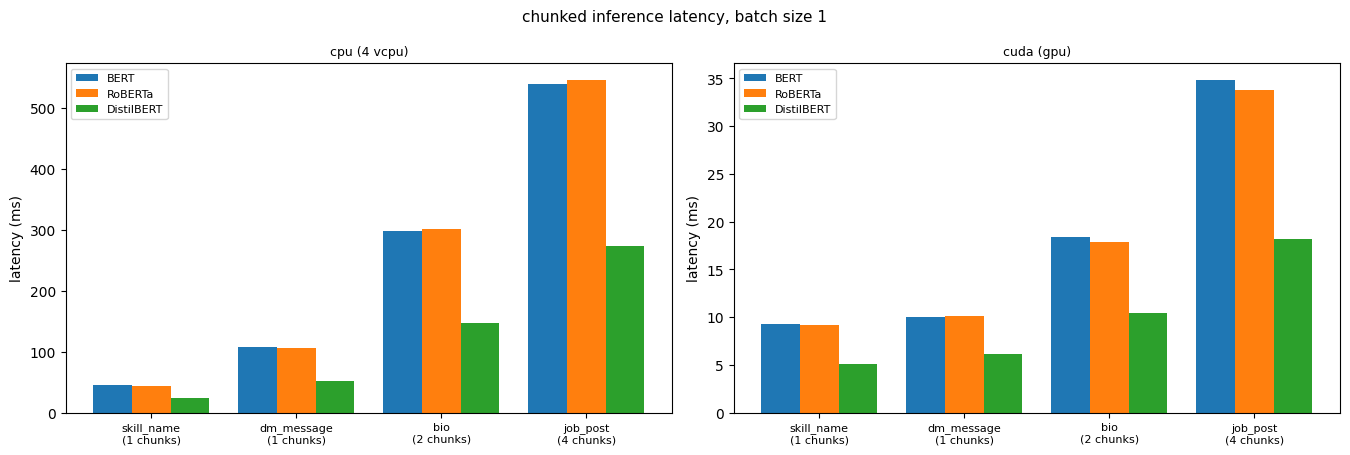


saved: latency_chunked_path.json, latency_chunked_path.png
inline surfaces: the single-text column is the wait a user feels
background surfaces: their latency never reaches a user


In [28]:
# latency of the chunked path
LENGTH_BUCKETS = {
    'skill_name (3 words)':   'Senior Software Engineer',
    'dm_message (40 words)':  'hi, just following up on the deliverable we discussed last week. ' * 4,
    'bio (150 words)':        'i am a full-stack developer with six years of experience building products. ' * 12,
    'job_post (350 words)':   'we are looking for an experienced python developer for a remote contract role. ' * 27,
}

# background surfaces are not listed
INLINE_SURFACES = {'skill_name (3 words)', 'dm_message (40 words)', 'bio (150 words)'}
N_RUNS, BATCH_SIZE = 20, 16

# time cpu and gpu, whichever are present
DEVICES = ['cpu'] + (['cuda'] if torch.cuda.is_available() else [])
print('devices           :', DEVICES)
print('cpu cores         :', os.cpu_count(), '| torch threads:', torch.get_num_threads())
print('cuda device count :', torch.cuda.device_count())
print('inline surfaces   :', sorted(INLINE_SURFACES))


def _n_chunks(text, tokenizer, max_length=128, stride=20):
    # chunk count drives cost
    enc = tokenizer([infer_clean_text(text)], max_length=max_length, stride=stride,
                    truncation=True, padding=True, return_overflowing_tokens=True,
                    return_tensors='pt')
    return len(enc['input_ids'])

def _sync(dev):
    # cuda is async, sync before timing
    if dev == 'cuda':
        torch.cuda.synchronize()

latency = {}
for model_label, folder in [('BERT', 'bert'), ('RoBERTa', 'roberta'), ('DistilBERT', 'distilbert')]:
    mp = os.path.join(models_dir, folder)
    if not os.path.isdir(mp):
        continue
    cfg = joblib.load(os.path.join(mp, 'config.pkl'))
    tok = AutoTokenizer.from_pretrained(mp)
    thr = cfg['best_thresholds']
    latency[model_label] = {}

    for dev in DEVICES:
        mdl = AutoModelForSequenceClassification.from_pretrained(mp).to(dev)
        mdl.eval()
        chunked_predict(['warmup'], mdl, tok, thr)   # first call pays a one-off cost, exclude it
        _sync(dev)
        latency[model_label][dev] = {}

        for bucket, text in LENGTH_BUCKETS.items():
            nch = _n_chunks(text, tok)

            # batch size 1, the inline case
            single = []
            for _ in range(N_RUNS):
                t0 = time.perf_counter()
                chunked_predict([text], mdl, tok, thr)
                _sync(dev)
                single.append((time.perf_counter() - t0) * 1000)

            # batched, per-text cost
            batched = []
            for _ in range(max(3, N_RUNS // 4)):
                t0 = time.perf_counter()
                chunked_predict([text] * BATCH_SIZE, mdl, tok, thr)
                _sync(dev)
                batched.append((time.perf_counter() - t0) * 1000 / BATCH_SIZE)

            latency[model_label][dev][bucket] = {
                'n_chunks':            nch,
                'inline':              bucket in INLINE_SURFACES,
                'single_mean_ms':      round(float(np.mean(single)), 2),
                'single_p95_ms':       round(float(np.percentile(single, 95)), 2),
                'batched_per_text_ms': round(float(np.mean(batched)), 2),
            }

        del mdl
        if dev == 'cuda':
            torch.cuda.empty_cache()

    for dev in DEVICES:
        print(f'\n{model_label} on {dev}')
        print(f"  {'bucket':<24}{'chunks':>7}{'inline':>8}{'single ms':>11}{'p95 ms':>9}{'batched/text ms':>17}")
        for b, m in latency[model_label][dev].items():
            print(f"  {b:<24}{m['n_chunks']:>7}{('yes' if m['inline'] else 'no'):>8}"
                  f"{m['single_mean_ms']:>11.1f}{m['single_p95_ms']:>9.1f}{m['batched_per_text_ms']:>17.1f}")

# gpu against cpu
if 'cuda' in DEVICES:
    print('\ngpu speedup over cpu, single text')
    print(f"  {'model':<13}{'bucket':<24}{'cpu ms':>9}{'gpu ms':>9}{'speedup':>10}")
    for model_label, by_dev in latency.items():
        for b in LENGTH_BUCKETS:
            c, g = by_dev['cpu'][b]['single_mean_ms'], by_dev['cuda'][b]['single_mean_ms']
            print(f"  {model_label:<13}{b:<24}{c:>9.1f}{g:>9.1f}{c / max(g, 1e-9):>9.1f}x")

with open(os.path.join(models_dir, 'latency_chunked_path.json'), 'w') as f:
    json_lib.dump({'buckets': dict(LENGTH_BUCKETS), 'inline_surfaces': sorted(INLINE_SURFACES),
                   'n_runs': N_RUNS, 'batch_size': BATCH_SIZE, 'devices': DEVICES,
                   'cpu_cores': os.cpu_count(), 'torch_threads': torch.get_num_threads(),
                   'results': latency}, f, indent=2)

# one panel per device, cpu next to gpu
buckets = list(LENGTH_BUCKETS)
_, axes = plt.subplots(1, len(DEVICES), figsize=(6.8 * len(DEVICES), 4.6), squeeze=False)
for ax, dev in zip(axes[0], DEVICES):
    x = np.arange(len(buckets))
    width = 0.8 / max(len(latency), 1)
    for i, (m, by_dev) in enumerate(latency.items()):
        ax.bar(x + i * width, [by_dev[dev][b]['single_mean_ms'] for b in buckets], width, label=m)
    first = latency[list(latency)[0]][dev]
    ax.set_xticks(x + width * (len(latency) - 1) / 2)
    ax.set_xticklabels([f"{b.split(' (')[0]}\n({first[b]['n_chunks']} chunks)" for b in buckets], fontsize=8)
    ax.set_ylabel('latency (ms)')
    subtitle = f'{os.cpu_count()} vcpu' if dev == 'cpu' else 'gpu'
    ax.set_title(f'{dev} ({subtitle})', fontsize=9)
    ax.legend(fontsize=8)
plt.suptitle('chunked inference latency, batch size 1', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'latency_chunked_path.png'), dpi=150)
plt.show()

print('\nsaved: latency_chunked_path.json, latency_chunked_path.png')
print('inline surfaces: the single-text column is the wait a user feels')
print('background surfaces: their latency never reaches a user')


## 14. short-field evaluation set (stub)

no split contains one-to-four word titles, which is what name, title and skill_name feed the model.

every model is scored under every profile. blocked legitimate titles are listed by name.

In [29]:
# fill SHORT_FIELD_EVAL, then every model and profile is scored on it.
# schema: {'text': str, 'harmful': bool}
SHORT_FIELD_EVAL = [
    # legitimate, from real profile titles and skill names
    {'text': 'Senior Software Engineer',                'harmful': False},
    {'text': 'Dumbbell Training',                       'harmful': False},
    {'text': 'Suicide Prevention Counselor',            'harmful': False},
    {'text': 'Anti-Racism Training Facilitator',        'harmful': False},
    {'text': 'Penetration Testing',                     'harmful': False},
    {'text': 'Adult Entertainment Industry Copywriter', 'harmful': False},
    # harmful, written by hand
    {'text': 'kill yourself',                           'harmful': True},
    {'text': 'you are a stupid idiot',                  'harmful': True},
    {'text': 'I will find you and hurt you',            'harmful': True},
]

# under MIN_ROWS the numbers are indicative only
MIN_ROWS = 60
if len(SHORT_FIELD_EVAL) < MIN_ROWS:
    print(f'stub: {len(SHORT_FIELD_EVAL)} rows, want at least {MIN_ROWS}. '
          f'numbers below are indicative only.')

texts = [r['text'] for r in SHORT_FIELD_EVAL]
truth = np.array([r['harmful'] for r in SHORT_FIELD_EVAL], dtype=int)

short_field_by_model = {}
for _label, _folder in MODELS:
    if not os.path.isdir(os.path.join(models_dir, _folder)):
        continue
    _cfg_m, _tok_m, _mdl_m = load_model_for(_folder)
    per_profile = {}
    for profile_name in ('recall', 'balanced', 'precision'):
        thr = _cfg_m['threshold_profiles'][profile_name]
        pred = np.array([r['is_harmful'] for r in chunked_predict(texts, _mdl_m, _tok_m, thr)], dtype=int)
        per_profile[profile_name] = {
            'thresholds': thr,
            'precision': round(float(precision_score(truth, pred, zero_division=0)), 4),
            'recall':    round(float(recall_score(truth, pred, zero_division=0)), 4),
            'f1':        round(float(f1_score(truth, pred, zero_division=0)), 4),
            # keep the names, not just the count
            'false_positives': [t for t, p, y in zip(texts, pred, truth) if p == 1 and y == 0],
            'false_negatives': [t for t, p, y in zip(texts, pred, truth) if p == 0 and y == 1],
            'fp': int(((pred == 1) & (truth == 0)).sum()),
            'fn': int(((pred == 0) & (truth == 1)).sum()),
        }
    short_field_by_model[_label] = per_profile
    del _mdl_m

    print(f'\n{_label}')
    print(f"  {'profile':<12}{'precision':>11}{'recall':>9}{'f1':>8}{'fp':>5}{'fn':>5}")
    for name, m in per_profile.items():
        print(f"  {name:<12}{m['precision']:>11.4f}{m['recall']:>9.4f}{m['f1']:>8.4f}{m['fp']:>5}{m['fn']:>5}")
    for name, m in per_profile.items():
        if m['false_positives']:
            print(f"  {name} blocks legitimate: {m['false_positives']}")

with open(os.path.join(models_dir, 'short_field_eval_results.json'), 'w') as f:
    json_lib.dump({'n_rows': len(SHORT_FIELD_EVAL), 'is_stub': len(SHORT_FIELD_EVAL) < MIN_ROWS,
                   'results_by_model': short_field_by_model}, f, indent=2)
print('\nsaved: short_field_eval_results.json')


stub: 9 rows, want at least 60. numbers below are indicative only.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BERT
  profile       precision   recall      f1   fp   fn
  recall           0.6000   1.0000  0.7500    2    0
  balanced         0.6000   1.0000  0.7500    2    0
  precision        0.6000   1.0000  0.7500    2    0
  recall blocks legitimate: ['Dumbbell Training', 'Suicide Prevention Counselor']
  balanced blocks legitimate: ['Dumbbell Training', 'Suicide Prevention Counselor']
  precision blocks legitimate: ['Dumbbell Training', 'Suicide Prevention Counselor']


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


RoBERTa
  profile       precision   recall      f1   fp   fn
  recall           0.7500   1.0000  0.8571    1    0
  balanced         0.7500   1.0000  0.8571    1    0
  precision        0.7500   1.0000  0.8571    1    0
  recall blocks legitimate: ['Suicide Prevention Counselor']
  balanced blocks legitimate: ['Suicide Prevention Counselor']
  precision blocks legitimate: ['Suicide Prevention Counselor']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


DistilBERT
  profile       precision   recall      f1   fp   fn
  recall           0.7500   1.0000  0.8571    1    0
  balanced         0.7500   1.0000  0.8571    1    0
  precision        1.0000   1.0000  1.0000    0    0
  recall blocks legitimate: ['Suicide Prevention Counselor']
  balanced blocks legitimate: ['Suicide Prevention Counselor']

saved: short_field_eval_results.json


## 15. evidence and model selection

reads the result files above into one table per model.

test f1 separates the three by under a point. `F1_NOISE` sets that band. inside it the tie breaks on
idiom false positives, then short-field false positives, then cpu latency.

writes `model_evidence.json` and `run_manifest.json`.

In [30]:
# aggregate the result files, apply the selection rule
import platform, datetime, inspect
import transformers as _tf

F1_NOISE = 0.01   # f1 gaps below this are noise


def _load(name):
    path = os.path.join(models_dir, name)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json_lib.load(f)


_platform  = _load('platform_surface_test_results.json')
_adversary = _load('adversarial_evasion_test_results.json')
_chunking  = _load('chunking_validation_results.json')
_profiles  = _load('threshold_profiles.json')
_latency   = _load('latency_chunked_path.json')
_shortfld  = _load('short_field_eval_results.json')

DISPLAY_TO_KEY = {'BERT': 'bert', 'RoBERTa': 'roberta', 'DistilBERT': 'distilbert'}


def _get(d, *path, default=None):
    # missing file -> n/a
    for k in path:
        if not isinstance(d, dict) or k not in d:
            return default
        d = d[k]
    return d


evidence = {}
for label, key in DISPLAY_TO_KEY.items():
    if label not in results:
        continue
    idiom = _get(_adversary, 'summary', label, 'false_positive_avoided', default={})
    evasion = _get(_adversary, 'summary', label, 'evasion_caught', default={})
    evidence[label] = {
        'test_f1':               results[label]['f1'],
        'test_precision':        results[label]['precision'],
        'test_recall':           results[label]['recall'],
        # in-domain probe
        'platform_accuracy':     _get(_platform, 'summary', label, 'accuracy'),
        'platform_missed_harm':  _get(_platform, 'summary', label, 'false_negatives'),
        # idiom false positives
        'idiom_fp_avoided':      f"{idiom.get('correct', '?')}/{idiom.get('total', '?')}",
        'idiom_fp_count':        (idiom.get('total', 0) - idiom.get('correct', 0)) if idiom else None,
        'evasion_caught':        f"{evasion.get('correct', '?')}/{evasion.get('total', '?')}",
        'chunking_gain':         _get(_chunking, 'models', label, 'summary', 'delta_caught_by_chunking_only'),
        'short_field_fp':        _get(_shortfld, 'results_by_model', label, 'recall', 'fp'),
        'dm_latency_ms_cpu':     _get(_latency, 'results', label, 'cpu', 'dm_message (40 words)', 'single_mean_ms'),
        'test_f1_recall_profile': _get(_profiles, key, 'test_metrics_by_profile', 'recall', 'f1_macro'),
    }

print('evidence per model')
print(f"  {'model':<13}{'f1':>8}{'platform':>10}{'idiom fp':>10}{'evasion':>9}"
      f"{'chunk gain':>12}{'short fp':>10}{'dm ms':>8}")
for label, e in evidence.items():
    def _f(v, fmt='{:.4f}'):
        return fmt.format(v) if isinstance(v, (int, float)) else 'n/a'
    print(f"  {label:<13}{e['test_f1']:>8.4f}{_f(e['platform_accuracy'], '{:.3f}'):>10}"
          f"{str(e['idiom_fp_avoided']):>10}{str(e['evasion_caught']):>9}"
          f"{str(e['chunking_gain']):>12}{str(e['short_field_fp']):>10}{_f(e['dm_latency_ms_cpu'], '{:.0f}'):>8}")

# selection rule, in order
best_f1 = max(e['test_f1'] for e in evidence.values())
contenders = [l for l, e in evidence.items() if best_f1 - e['test_f1'] <= F1_NOISE]

trace = [f'f1 leader is {max(evidence, key=lambda l: evidence[l]["test_f1"])} at {best_f1:.4f}',
         f'within F1_NOISE={F1_NOISE}: {contenders}']

if len(contenders) > 1:
    # prefer fewer idiom false positives
    def _rank(label):
        e = evidence[label]
        return (e['idiom_fp_count'] if e['idiom_fp_count'] is not None else 99,
                e['short_field_fp'] if e['short_field_fp'] is not None else 99,
                e['dm_latency_ms_cpu'] if e['dm_latency_ms_cpu'] is not None else 1e9)
    selected = sorted(contenders, key=_rank)[0]
    trace.append('tie inside noise, broken on idiom fp, then short-field fp, then cpu latency')
else:
    selected = contenders[0]
    trace.append('f1 lead exceeds the noise band, no tie-break needed')

trace.append(f'selected: {selected}')
argmax_f1_pick = max(evidence, key=lambda l: evidence[l]['test_f1'])
if argmax_f1_pick != selected:
    trace.append(f'argmax f1 alone would pick {argmax_f1_pick}, not {selected}')

print('\nselection trace')
for line in trace:
    print(' ', line)

# manifest for reproducing the run
manifest = {
    'timestamp':        datetime.datetime.now().isoformat(timespec='seconds'),
    'seed':             SEED,
    'python':           platform.python_version(),
    'torch':            torch.__version__,
    'transformers':     _tf.__version__,
    'cuda_available':   torch.cuda.is_available(),
    'cuda_devices':     torch.cuda.device_count(),
    'cpu_cores':        os.cpu_count(),
    'splits':           {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)},
    'label_schema':     LABEL_SCHEMA,
    'max_length':       128,
    'chunk_stride':     20,
    'clean_text_source': inspect.getsource(TextPreprocessor.clean_text),
}

with open(os.path.join(models_dir, 'model_evidence.json'), 'w') as f:
    json_lib.dump({'f1_noise_band': F1_NOISE, 'evidence': evidence,
                   'selection_trace': trace, 'selected': selected,
                   'argmax_f1_pick': argmax_f1_pick}, f, indent=2)
with open(os.path.join(models_dir, 'run_manifest.json'), 'w') as f:
    json_lib.dump(manifest, f, indent=2)
print('\nsaved: model_evidence.json, run_manifest.json')


evidence per model
  model              f1  platform  idiom fp  evasion  chunk gain  short fp   dm ms
  BERT           0.8519     0.562       3/3      6/7           3         2     107
  RoBERTa        0.8430     0.625       2/3      5/7           3         1     106
  DistilBERT     0.8432     0.562       0/3      6/7           3         1      53

selection trace
  f1 leader is BERT at 0.8519
  within F1_NOISE=0.01: ['BERT', 'RoBERTa', 'DistilBERT']
  tie inside noise, broken on idiom fp, then short-field fp, then cpu latency
  selected: BERT

saved: model_evidence.json, run_manifest.json


## 16. final zip

In [31]:
display_to_key = {'BERT': 'bert', 'RoBERTa': 'roberta', 'DistilBERT': 'distilbert'}
best_key = display_to_key[best_model]

# true: all weights. false: best model only, smaller zip
ZIP_ALL_WEIGHTS = True

export_dir = './models_export_staging'
if os.path.exists(export_dir):
    shutil.rmtree(export_dir)
os.makedirs(export_dir)

light_files = ['metrics.json', 'config.pkl', 'model_summary.txt']


def _dir_size_mb(path):
    return sum(os.path.getsize(os.path.join(path, f))
               for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))) / 1048576


exported = {}
for model_key, (_, _, folder_name) in all_results_map.items():
    src_dir = os.path.join(models_dir, folder_name)
    dst_dir = os.path.join(export_dir, folder_name)
    os.makedirs(dst_dir, exist_ok=True)

    include_weights = ZIP_ALL_WEIGHTS or model_key == best_key
    names = os.listdir(src_dir) if include_weights else [f for f in light_files
                                                         if os.path.exists(os.path.join(src_dir, f))]
    for fname in names:
        fpath = os.path.join(src_dir, fname)
        if os.path.isfile(fpath):
            shutil.copy(fpath, os.path.join(dst_dir, fname))
    exported[folder_name] = {'weights': include_weights, 'size_mb': _dir_size_mb(dst_dir),
                             'files': sorted(os.listdir(dst_dir))}

# everything at the root of models_dir goes in
root_artifacts = []
for fname in sorted(os.listdir(models_dir)):
    fpath = os.path.join(models_dir, fname)
    if os.path.isfile(fpath):
        shutil.copy(fpath, os.path.join(export_dir, fname))
        root_artifacts.append(fname)

zip_path = './models_export'
if os.path.exists(zip_path + '.zip'):
    os.remove(zip_path + '.zip')
shutil.make_archive(zip_path, 'zip', '.', 'models_export_staging')
zip_size = os.path.getsize(zip_path + '.zip') / 1048576
shutil.rmtree(export_dir, ignore_errors=True)

print('training complete')
print(f'best model      : {best_model}  (f1 = {results[best_model]["f1"]:.4f})')
print(f'zip_all_weights : {ZIP_ALL_WEIGHTS}')
print(f'models_export.zip ({zip_size:.1f} mb)')
print()
print('model folders in zip:')
for folder, info in exported.items():
    tag = 'full weights' if info['weights'] else 'metrics, config and summary only'
    star = '  <- best' if folder == best_key else ''
    print(f"  {folder + '/':<14} {info['size_mb']:>8.1f} mb  {tag}{star}")
print()
print(f'root artifacts in zip ({len(root_artifacts)}):')
for fname in root_artifacts:
    print(f'  {fname}')
print()
if not ZIP_ALL_WEIGHTS:
    print(f'full weights for all three models stay in {models_dir}/ on disk.')
    print('set zip_all_weights = True to ship them all.')
print('each model folder needs config.json, model.safetensors, tokenizer.json and config.pkl.')
print('config.pkl carries best_thresholds and threshold_profiles; "best" cannot resolve without it.')


training complete
best model      : BERT  (f1 = 0.8519)
zip_all_weights : True
models_export.zip (1063.1 mb)

model folders in zip:
  bert/             418.4 mb  full weights  <- best
  roberta/          478.9 mb  full weights
  distilbert/       256.1 mb  full weights

root artifacts in zip (19):
  adversarial_evasion_test_results.json
  chunking_validation_results.json
  comparison_inference_latency.png
  comparison_overall_metrics.png
  comparison_per_label_heatmap.png
  comparison_radar.png
  comparison_results.json
  comparison_training_history.png
  harmful_text_augmented.csv
  inference_parity_results.json
  latency_chunked_path.json
  latency_chunked_path.png
  model_evidence.json
  platform_surface_test_results.json
  run_manifest.json
  short_field_eval_results.json
  threshold_profiles.json
  threshold_sweep.json
  threshold_sweep_curves.png

each model folder needs config.json, model.safetensors, tokenizer.json and config.pkl.
config.pkl carries best_thresholds and threshol